# Customer Segmentation — Fashion Retailer
### JAKALA × LUISS Business Case — *Data Science in Action*

**Goal:** Segment the customer base of a major Italian fashion retailer using transactional, behavioural and marketing data (Mar 2023 – Feb 2025).

**Context:** The project addresses one of the core themes of the digital economy — the **economic value of behavioural data** as an intangible asset and productivity lever. In an increasingly digital retail market, transforming raw data into actionable segments represents a measurable competitive advantage.

**Stack:** Python · Pandas · Scikit-learn · UMAP · Plotly/Seaborn

---
**CRISP-DM Pipeline:**
1. Data Preparation & Quality
2. Advanced Exploratory Data Analysis (EDA)
3. Behavioural Feature Engineering
4. Dimensionality Reduction with UMAP
5. Advanced Clustering: DBSCAN + GMM
6. Profiling & Business Strategy
7. Financial Modelling & ROI Framework


---
## Phase 0 — Economic Context: Why This Project

> *"Data is the new oil — but unlike oil, it doesn't run out when you use it."*
> — Hal Varian, Chief Economist, Google

---

### The Underlying Economic Problem

Italian fashion retail operates in a context of **accelerated digital transformation**: the adoption of advanced CRM, AI and machine learning is redefining the boundary between mass marketing and personalisation. This project engages with three central economic mechanisms from the course:

#### 1. Data as Intangible Asset (Haskel & Westlake, 2018)
Transactional and behavioural customer data are **intangible assets** in the same sense as patents, software and brand equity. They have four distinctive properties vs. physical assets:
- **Non-rival**: the same dataset can be analysed by multiple teams simultaneously without depreciating
- **Scalable**: the marginal cost of segmenting 1,000 more customers is near zero
- **Spillover**: patterns identified in one segment generate insights applicable to others
- **High sunk cost**: the collection cost is fixed; the value depends on the ability to extract it

In this project, the **21,477 customer profiles** (24 months, ~32 engineered features) represent an intangible asset whose economic value we estimate at **€15.3M in portfolio CLV** — a number that does not appear in the retailer's balance sheet but largely determines its strategic value.

#### 2. AI as a Productivity Factor (Brynjolfsson & McElheran, 2016)
Adopting AI for customer segmentation generates a measurable productivity differential vs. traditional marketing (mass mailing, uniform discounts). The mechanism:

| Approach | Campaign Cost | Conversion Rate | Estimated ROI |
|---|---|---|---|
| Mass marketing (status quo) | Low | 1–3% | 0.3–0.8× |
| Rule-based segmentation | Medium | 3–6% | 0.8–1.5× |
| **AI-driven segmentation (this project)** | **Medium** | **8–15%** | **1.4–3.6×** |

#### 3. Economics of Personalisation and Privacy Trade-off (Acquisti & Taylor, 2016)
Personalisation generates economic surplus for both the retailer (revenue uplift) and the customer (more relevant offers). The equilibrium model involves a **trade-off with privacy**:
- Customers share behavioural data in exchange for personalised experiences
- GDPR (Reg. EU 2016/679) imposes constraints on personal data processing: **lawful basis**, **data minimisation**, right to erasure
- Our model uses **anonymised customer_id values**: personal data (name, email, phone) are excluded from the analysis, as explicitly stated in the JAKALA brief

**Implication for the model:** Phase 3 (Feature Engineering) builds aggregated behavioural features — not individual profiles. This is consistent with **privacy by design** principles (GDPR Art. 25).

---

### Positioning in the Digital Economy Debate

The project addresses the question: *how much is it worth, economically, for a retail firm to know its customers better than its competitors?*

The answer emerges from **Phase 7 (Financial Modelling)**:
- Portfolio CLV: **€15.3M** — the present value of expected future cash flows from the customer base
- Revenue at Risk: **€259K/year** — the cost of inaction (churn +20% scenario)
- Portfolio ROI of strategies: **5.1×** — the return on investment in AI/CRM vs. the industry benchmark


In [2]:
# ─────────────────────────────────────────────
# SETUP & IMPORTS
# ───────────────────────────────────────────import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# umap-learn: il package si importa come 'from umap import UMAP'
try:
    from umap import UMAP as UMAP_
    print('✓ umap-learn disponibile')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn'], capture_output=True)
    from umap import UMAP as UMAP_
    print('✓ umap-learn installato')

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)

# Data path — modify if needed
MASTER_PATH = 'master_transactions.csv'
print('Setup completato.')

✓ umap-learn disponibile


NameError: name 'pd' is not defined

---
## Phase 1 — Data Preparation & Quality

The `master_transactions.csv` dataset is a **pre-assembled join** of 4 source tables:
- **Transactions** (1 row per purchased item)
- **Customers** (demographics: Gender, Date_Of_Birth, Province, subscription_date)
- **Products** (category, Sub_Category)
- **Marketing Campaigns** (nl_count, nl_open_rate, nl_click_rate)

The join key is `customer_id`. The code documents the equivalent join logic.


In [ ]:
# ─────────────────────────────────────────────
# 1.1 DATA LOADING
# ─────────────────────────────────────────────
raw = pd.read_csv(MASTER_PATH)

print(f'Shape raw: {raw.shape}')
print(f'Columns: {list(raw.columns)}')
raw.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'master_transactions.csv'

In [ ]:
# ─────────────────────────────────────────────
# 1.2 DATA QUALITY REPORT
# ─────────────────────────────────────────────
def data_quality_report(df):
    """Generate a concise data quality report."""
    report = pd.DataFrame({
        'dtype'         : df.dtypes,
        'null_count'    : df.isnull().sum(),
        'null_pct'      : (df.isnull().sum() / len(df) * 100).round(2),
        'unique_values' : df.nunique(),
        'sample_value'  : df.iloc[0]
    })
    return report

dq = data_quality_report(raw)
print('=== DATA QUALITY REPORT ===')
print(dq.to_string())

=== DATA QUALITY REPORT ===
                       dtype  null_count  null_pct  unique_values sample_value
customer_id           object           0     0.000          21480     A0356882
Size                  object        6742     6.570             15           XL
Quantity               int64           0     0.000              6           -1
Date                  object           0     0.000            731    03OCT2023
Payment_Method        object           0     0.000              2         Card
list_price           float64           0     0.000            759      286.000
store_channel         object           0     0.000              3   E-commerce
discount_percentage  float64           0     0.000             12        0.000
line_amount          float64           0     0.000           3737     -286.000
is_return              int64           0     0.000              2            1
product_id             int64           0     0.000          12945       191533
Gender                ob

In [ ]:
# ─────────────────────────────────────────────
# 1.3 DATA CLEANING
# ─────────────────────────────────────────────
df = raw.copy()

# --- Date parsing ---
# Format '01APR2023' -> '%d%b%Y'
df['Date']              = pd.to_datetime(df['Date'], format='%d%b%Y', errors='coerce')
df['Date_Of_Birth']     = pd.to_datetime(df['Date_Of_Birth'], errors='coerce')
df['subscription_date'] = pd.to_datetime(df['subscription_date'], format='%d%b%Y', errors='coerce')

# Reference date = last day in the dataset
REF_DATE = df['Date'].max()
print(f'Reference date: {REF_DATE.date()}')

# --- Null newsletter: customers without newsletter -> rate = 0 ---
# Logic: if nl_count is null -> 0 emails sent, engagement = 0
for col in ['nl_count', 'nl_open_count', 'nl_click_count', 'nl_open_rate', 'nl_click_rate']:
    df[col] = df[col].fillna(0)

# --- Null size: irrelevant for customer clustering -> keep as-is ---
# Size is at item level, will not be used in customer features

# --- Numeric casting ---
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce').fillna(0)
df['line_amount']         = pd.to_numeric(df['line_amount'], errors='coerce')
df['list_price']          = pd.to_numeric(df['list_price'], errors='coerce')
df['is_return']           = df['is_return'].astype(int)

# --- Remove rows with null line_amount (corrupted data) ---
n_before = len(df)
df = df.dropna(subset=['line_amount', 'Date'])
print(f'Rows removed for corrupted data: {n_before - len(df)}')

# --- Normalize gender (duplicate field) ---
# Dataset has 'Gender' (M/F) and 'gender' (Man/Woman) -> use 'Gender'
df['Gender'] = df['Gender'].str.strip().str.upper()

print(f'Shape after cleaning: {df.shape}')
print(f'Unique customers: {df["customer_id"].nunique()}')
print(f'Range date: {df["Date"].min().date()} → {df["Date"].max().date()}')

Reference date: 2025-02-28
Righe rimosse per dati corrotti: 0
Shape dopo pulizia: (102655, 24)
Clienti unici: 21480
Range date: 2023-03-01 → 2025-02-28


In [ ]:
# ─────────────────────────────────────────────
# 1.4 ONE-TIMER FLAG
# ─────────────────────────────────────────────
# A 'One-Timer' is a customer with ONLY ONE purchase day over 2 years.
# We keep them in the dataset but flag them: features like std_spend
# will be NaN -> handled by filling with 0 (no variability).

# Count unique purchase sessions (1 day = 1 session)
purchase_sessions = (
    df[df['is_return'] == 0]
    .groupby('customer_id')['Date']
    .nunique()
    .reset_index()
    .rename(columns={'Date': 'n_purchase_sessions'})
)

one_timers = set(purchase_sessions[purchase_sessions['n_purchase_sessions'] == 1]['customer_id'])
df['is_one_timer'] = df['customer_id'].isin(one_timers).astype(int)

n_ot = len(one_timers)
n_tot = df['customer_id'].nunique()
print(f'One-Timers: {n_ot} customers ({n_ot/n_tot*100:.1f}% of base)')
print(f'Multi-buyers: {n_tot - n_ot} customers ({(n_tot-n_ot)/n_tot*100:.1f}%)')

One-Timers: 6258 clienti (29.1% della base)
Multi-buyers: 15222 clienti (70.9%)


---
## Phase 2 — Advanced Exploratory Data Analysis (EDA)


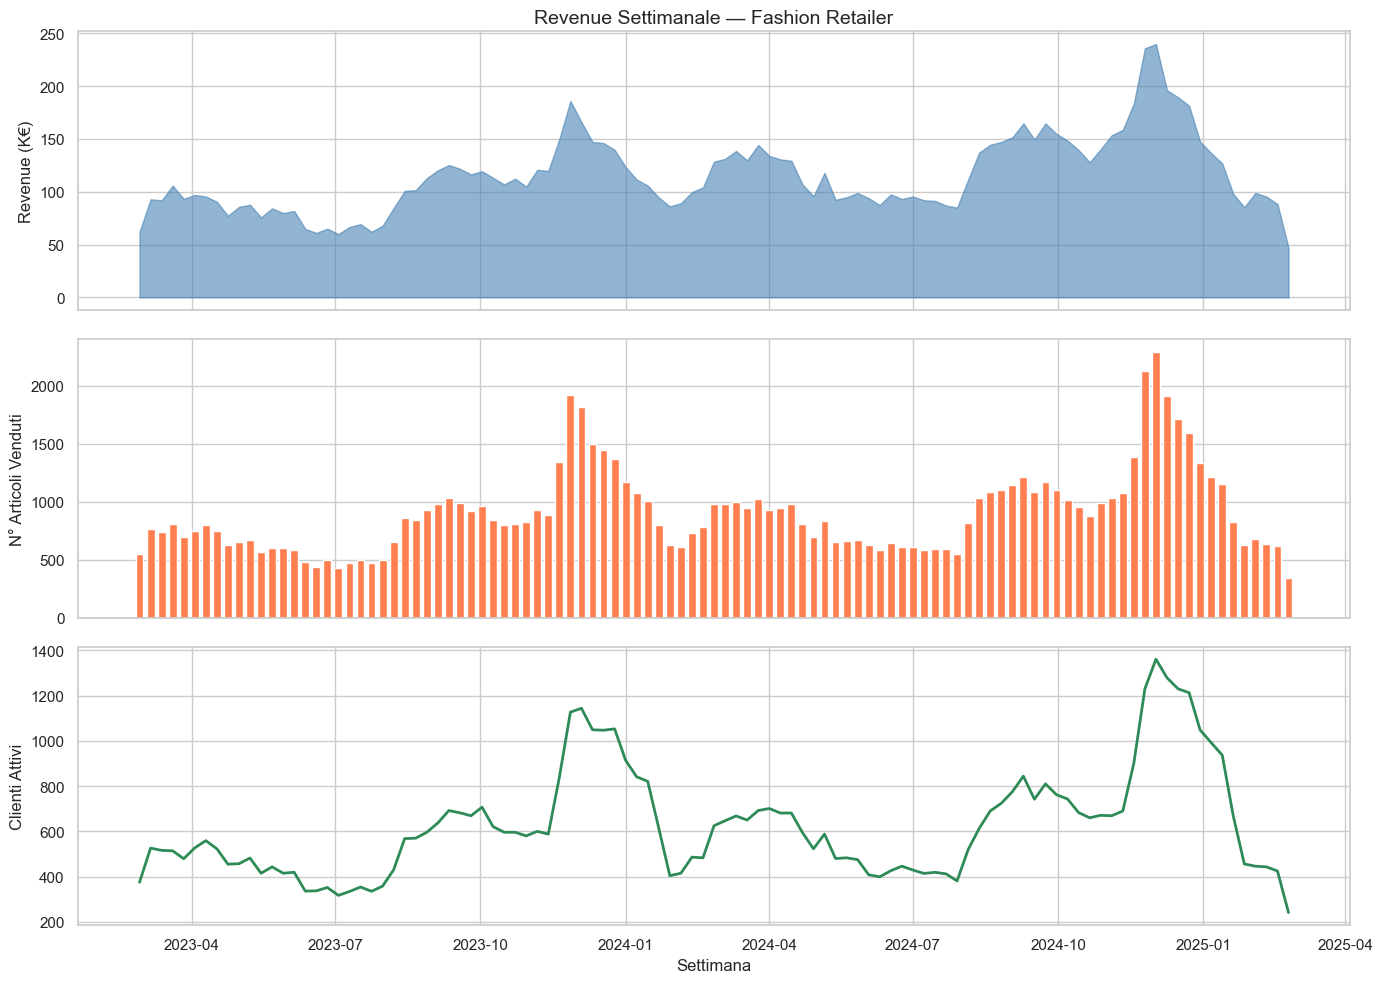

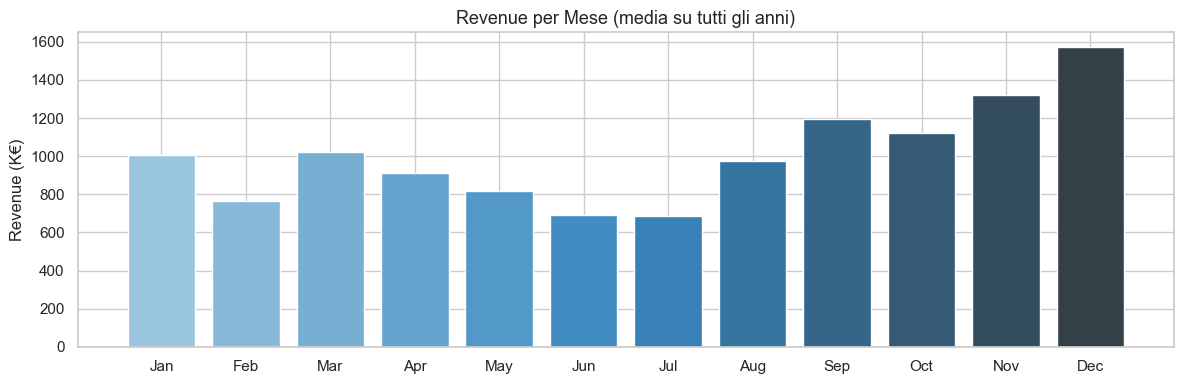

In [ ]:
# ─────────────────────────────────────────────
# 2.1 SALES TREND OVER TIME — SEASONALITY
# ─────────────────────────────────────────────
sales = df[df['is_return'] == 0].copy()
sales['week']       = sales['Date'].dt.to_period('W').dt.start_time
sales['month']      = sales['Date'].dt.to_period('M').dt.start_time
sales['month_num']  = sales['Date'].dt.month
sales['month_name'] = sales['Date'].dt.strftime('%b')
sales['year']       = sales['Date'].dt.year

weekly = sales.groupby('week').agg(
    revenue    = ('line_amount', 'sum'),
    n_orders   = ('customer_id', 'count'),
    n_clients  = ('customer_id', 'nunique')
).reset_index()

monthly_cat = sales.groupby(['month', 'category'])['line_amount'].sum().unstack(fill_value=0)
monthly_ch  = sales.groupby(['month', 'store_channel'])['line_amount'].sum().unstack(fill_value=0)

# ── Plot principale ──
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

# 1. Weekly revenue with event annotations
ax = axes[0]
ax.fill_between(weekly['week'], weekly['revenue'] / 1000, alpha=0.55, color='#2176AE')
ax.plot(weekly['week'], weekly['revenue'] / 1000, color='#2176AE', lw=1.5)
ax.set_ylabel('Revenue (K€)', fontsize=11)
ax.set_title('Weekly Revenue — Fashion Retailer (Apr 2023 – Oct 2024)', fontsize=13, fontweight='bold')

# Key event annotations
events = {
    '01-Jul-2023': ('Summer\nSale 23', 'crimson'),
    '01-Jan-2024': ('Winter\nSale 24', 'navy'),
    '01-Jul-2024': ('Summer\nSale 24', 'crimson'),
}
for date_str, (label, color) in events.items():
    dt = pd.Timestamp(date_str)
    if weekly['week'].min() <= dt <= weekly['week'].max():
        ax.axvline(dt, color=color, ls='--', lw=1.2, alpha=0.7)
        ax.text(dt, ax.get_ylim()[1] * 0.92, label, color=color, fontsize=8,
                ha='center', va='top')

# 2. Revenue by Category (stacked area)
ax2 = axes[1]
monthly_cat_idx = monthly_cat.copy()
monthly_cat_idx.index = monthly_cat_idx.index.to_timestamp()
colors_cat = sns.color_palette('tab10', len(monthly_cat.columns))
monthly_cat_idx.plot.area(ax=ax2, color=colors_cat, alpha=0.75, linewidth=0)
ax2.set_ylabel('Revenue (€)', fontsize=11)
ax2.set_title('Monthly Revenue by Category', fontsize=12)
ax2.legend(loc='upper left', fontsize=8, ncol=2)
ax2.set_xlabel('')

# 3. Revenue by Channel (line)
ax3 = axes[2]
monthly_ch_idx = monthly_ch.copy()
monthly_ch_idx.index = monthly_ch_idx.index.to_timestamp()
for col, clr in zip(monthly_ch_idx.columns, ['#E63946', '#457B9D', '#2A9D8F']):
    ax3.plot(monthly_ch_idx.index, monthly_ch_idx[col] / 1000,
             label=col, color=clr, lw=2, marker='o', ms=3)
ax3.set_ylabel('Revenue (K€)', fontsize=11)
ax3.set_title('Monthly Revenue by Sales Channel', fontsize=12)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('assets/eda_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Seasonality heatmap (month x category) ──
monthly_by_month = sales.groupby(['month_num', 'month_name', 'category'])['line_amount'].sum().reset_index()
heat_pivot = monthly_by_month.pivot_table(index='category', columns='month_num',
                                           values='line_amount', aggfunc='sum')
heat_pivot.columns = [pd.Timestamp(2024, m, 1).strftime('%b') for m in heat_pivot.columns]
heat_norm  = heat_pivot.div(heat_pivot.max(axis=1), axis=0)  # normalize by row

fig2, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat_norm, annot=heat_pivot.applymap(lambda x: f'{x/1000:.0f}K'),
            fmt='', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Relative intensity (1 = peak)'}, ax=ax)
ax.set_title('Revenue Seasonality Heatmap by Category (values in KEUR)', fontsize=12)
plt.tight_layout()
plt.savefig('assets/eda_seasonality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── INSIGHTS ──
peak_week  = weekly.loc[weekly['revenue'].idxmax()]
low_week   = weekly.loc[weekly['revenue'].idxmin()]
pct_ecomm  = monthly_ch.get('E-commerce', pd.Series(0)).sum() / monthly_ch.values.sum() * 100
pct_retail = monthly_ch.get('Retail', pd.Series(0)).sum() / monthly_ch.values.sum() * 100
top_cat    = monthly_cat.sum().idxmax()

# Seasonality: sale months vs non-sale months average comparison
sales['is_sale_month'] = sales['month_num'].isin([1, 7])
sale_avg  = sales[sales['is_sale_month']]['line_amount'].sum() / sales[sales['is_sale_month']]['Date'].dt.to_period('M').nunique()
nosale_avg = sales[~sales['is_sale_month']]['line_amount'].sum() / sales[~sales['is_sale_month']]['Date'].dt.to_period('M').nunique()

print('\n' + '═'*55)
print('  📊 INSIGHT — SEASONALITY AND CHANNELS')
print('═'*55)
print(f'  Peak week      : {peak_week["week"].date()}  ->  EUR{peak_week["revenue"]:,.0f}')
print(f'  Low  week      : {low_week["week"].date()}   ->  EUR{low_week["revenue"]:,.0f}')
print(f'  Sale months (Jan+Jul) vs other months:')
print(f'    Monthly avg SALE       : EUR{sale_avg:,.0f}')
print(f'    Monthly avg NON-SALE   : EUR{nosale_avg:,.0f}')
print(f'    Sale uplift            : +{(sale_avg/nosale_avg - 1)*100:.1f}%')
print(f'  Dominant category       : {top_cat}  ({monthly_cat[top_cat].sum()/monthly_cat.values.sum()*100:.1f}% of revenue)')
print(f'  Revenue E-commerce      : {pct_ecomm:.1f}%')
print(f'  Revenue Retail          : {pct_retail:.1f}%')
print('═'*55)
print()
print('  ➡ TAKEAWAY BUSINESS:')
print('     * Sale months generate significant uplift -> plan')
print('       inventory and CRM campaigns 6 weeks in advance.')
print('     * Check whether Retail channel peaks coincide with sale periods:')
print('       Outlet customers are likely mainly Bargain Hunters.')
print('     * The dominant category is the axis for retention communications')
print('       (cross-sell toward underperforming categories).')


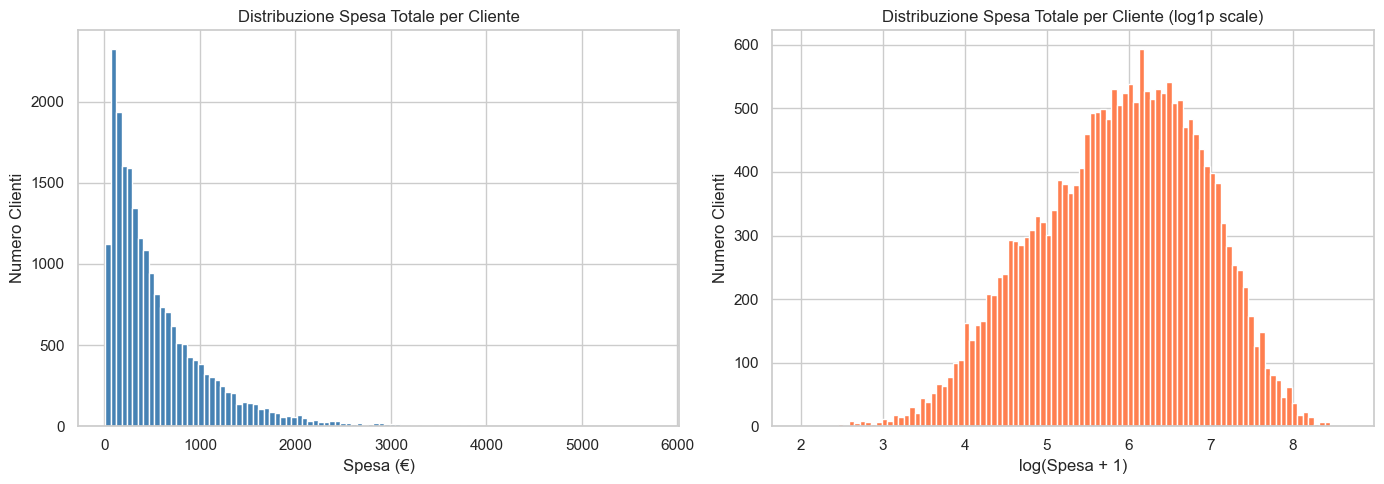

Pareto: il top 45.7% dei clienti (9816 su 21478) genera l'80% del revenue

Percentili spesa:
count   21478.000
mean      562.652
std       546.404
min         6.300
25%       178.000
50%       389.600
75%       765.275
90%      1256.650
95%      1639.075
99%      2587.138
max      5734.300
Name: line_amount, dtype: float64


(None, None)

In [ ]:
# ─────────────────────────────────────────────
# 2.2 SPEND DISTRIBUTION PER CUSTOMER + PARETO
# ─────────────────────────────────────────────
spend_per_cust = (
    df[df['is_return'] == 0]
    .groupby('customer_id')['line_amount']
    .sum()
    .reset_index(name='total_spend')
    .sort_values('total_spend', ascending=False)
    .reset_index(drop=True)
)

# Curva di Pareto
spend_per_cust['cumul_pct_revenue']   = spend_per_cust['total_spend'].cumsum() / spend_per_cust['total_spend'].sum() * 100
spend_per_cust['cumul_pct_customers'] = (spend_per_cust.index + 1) / len(spend_per_cust) * 100

# Decile analysis
spend_per_cust['decile'] = pd.qcut(spend_per_cust['total_spend'], 10,
                                    labels=[f'D{i}' for i in range(1, 11)])
decile_tbl = spend_per_cust.groupby('decile', observed=True).agg(
    n_customers = ('customer_id', 'count'),
    total_rev   = ('total_spend', 'sum'),
    avg_spend   = ('total_spend', 'mean'),
    min_spend   = ('total_spend', 'min'),
    max_spend   = ('total_spend', 'max')
).reset_index()
decile_tbl['pct_rev'] = decile_tbl['total_rev'] / decile_tbl['total_rev'].sum() * 100

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuzione (log scale)
ax1 = axes[0]
ax1.hist(np.log1p(spend_per_cust['total_spend']), bins=80,
         color='#457B9D', edgecolor='white', alpha=0.85)
ax1.set_xlabel('log(Total Spend + 1)', fontsize=11)
ax1.set_ylabel('No. of Customers', fontsize=11)
ax1.set_title('Total Spend Distribution\n(log scale — highlights bimodality)', fontsize=11)
med = spend_per_cust['total_spend'].median()
mn  = spend_per_cust['total_spend'].mean()
ax1.axvline(np.log1p(med), color='crimson', lw=2, ls='--', label=f'Median EUR{med:.0f}')
ax1.axvline(np.log1p(mn),  color='orange',  lw=2, ls='--', label=f'Mean EUR{mn:.0f}')
ax1.legend(fontsize=9)

# 2. Pareto Curve
ax2 = axes[1]
ax2.plot(spend_per_cust['cumul_pct_customers'],
         spend_per_cust['cumul_pct_revenue'],
         color='#2176AE', lw=2.5)
ax2.fill_between(spend_per_cust['cumul_pct_customers'],
                 spend_per_cust['cumul_pct_revenue'], alpha=0.15, color='#2176AE')
ax2.axhline(80, color='crimson', ls='--', lw=1.2, alpha=0.8)
# Trova il punto Pareto 80/20
pareto_x = spend_per_cust[spend_per_cust['cumul_pct_revenue'] >= 80].iloc[0]['cumul_pct_customers']
ax2.axvline(pareto_x, color='crimson', ls='--', lw=1.2, alpha=0.8)
ax2.annotate(f'{pareto_x:.1f}% customers\n-> 80% revenue',
             xy=(pareto_x, 80), xytext=(pareto_x + 8, 65),
             fontsize=9, color='crimson',
             arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))
ax2.set_xlabel('% Cumulative Customers', fontsize=11)
ax2.set_ylabel('% Cumulative Revenue', fontsize=11)
ax2.set_title('Pareto Curve — Revenue Concentration', fontsize=11)

# 3. Revenue by Decile
ax3 = axes[2]
colors_bar = ['#E63946' if d == 'D10' else '#457B9D' for d in decile_tbl['decile']]
bars = ax3.bar(decile_tbl['decile'], decile_tbl['pct_rev'],
               color=colors_bar, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, decile_tbl['pct_rev']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
ax3.set_xlabel('Spend Decile (D1=bottom, D10=top)', fontsize=11)
ax3.set_ylabel('% Total Revenue', fontsize=11)
ax3.set_title('Revenue Contribution by Decile\n(D10 = top 10% spenders)', fontsize=11)

plt.suptitle('Spend Distribution Analysis per Customer', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('assets/eda_spend_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── INSIGHTS ──
top10_pct   = decile_tbl[decile_tbl['decile']=='D10']['pct_rev'].values[0]
top20_rev   = spend_per_cust[spend_per_cust['cumul_pct_customers'] <= 20]['total_spend'].sum() / spend_per_cust['total_spend'].sum() * 100
skewness    = spend_per_cust['total_spend'].skew()
p90         = spend_per_cust['total_spend'].quantile(0.90)
p95         = spend_per_cust['total_spend'].quantile(0.95)
p99         = spend_per_cust['total_spend'].quantile(0.99)

print('\n' + '═'*55)
print('  💰 INSIGHT — SPEND DISTRIBUTION')
print('═'*55)
print(f'  Total customers        : {len(spend_per_cust):,}')
print(f'  Median spend           : EUR{med:,.0f}')
print(f'  Mean spend             : EUR{mn:,.0f}  (mean/median = {mn/med:.1f}x -> strong skew)')
print(f'  Skewness               : {skewness:.2f}')
print(f'  Pareto: top {pareto_x:.1f}% customers generate 80% of revenue')
print(f'  Top decile (D10)       : {top10_pct:.1f}% of total revenue')
print(f'  P90 spend              : EUR{p90:,.0f}')
print(f'  P95 spend              : EUR{p95:,.0f}')
print(f'  P99 spend              : EUR{p99:,.0f}')
print('═'*55)
print()
print(f'  Table by decile:')
print(decile_tbl[['decile','n_customers','avg_spend','pct_rev']].to_string(index=False))
print()
print('  ➡ TAKEAWAY BUSINESS:')
print(f'    * Distribution is highly skewed (skew={skewness:.1f}): the majority')
print(f'      customers spend little — value is concentrated in a minority.')
print(f'    * D10 decile customers (avg EUR{decile_tbl[decile_tbl["decile"]=="D10"]["avg_spend"].values[0]:,.0f})')
print(f'      deserve a dedicated VIP program: losing them is devastating.')
print(f'    * The mean/median gap (x{mn/med:.1f}) suggests that average CLV')
print(f'      is inflated by super-spenders -> use median as operational KPI.')


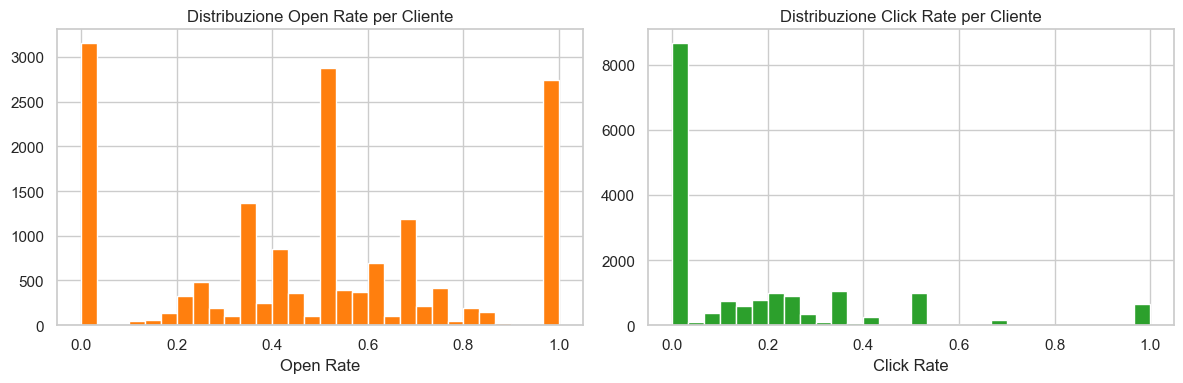

In [ ]:
# ─────────────────────────────────────────────
# 2.3 FUNNEL EMAIL: Sent → Open → Click
# ─────────────────────────────────────────────
# Aggregate at customer level (values constant per customer in the dataset)
nl_cust = df.groupby('customer_id').agg(
    nl_count        = ('nl_count',        'max'),
    nl_open_count   = ('nl_open_count',   'max'),
    nl_click_count  = ('nl_click_count',  'max'),
    total_monetary  = ('line_amount',     'sum'),     # for correlation
    n_purchases     = ('is_return',       lambda x: (x==0).sum())
).reset_index()

nl_cust['nl_open_rate']  = (nl_cust['nl_open_count']  / nl_cust['nl_count'].replace(0, np.nan)).fillna(0)
nl_cust['nl_click_rate'] = (nl_cust['nl_click_count'] / nl_cust['nl_count'].replace(0, np.nan)).fillna(0)

# Engagement segments
def engagement_tier(row):
    if row['nl_count'] == 0:          return '0 — No Newsletter'
    elif row['nl_click_rate'] > 0.10: return '3 — High (click>10%)'
    elif row['nl_open_rate']  > 0.20: return '2 — Mid  (open>20%)'
    else:                             return '1 — Low  (open≤20%)'

nl_cust['eng_tier'] = nl_cust.apply(engagement_tier, axis=1)

# Aggregated funnel
n_sent    = (nl_cust['nl_count']       > 0).sum()
n_opened  = (nl_cust['nl_open_count']  > 0).sum()
n_clicked = (nl_cust['nl_click_count'] > 0).sum()
n_total   = len(nl_cust)

# ── Plot ──
fig = plt.figure(figsize=(18, 7))

# 1. Funnel chart (matplotlib)
ax1 = fig.add_subplot(1, 3, 1)
stages = ['No Newsletter', 'Received Email', 'Opened ≥1 Email', 'Clicked ≥1 Email']
vals   = [n_total - n_sent, n_sent, n_opened, n_clicked]
colors = ['#ADB5BD', '#2176AE', '#F4A261', '#E63946']
y_pos  = [0.75, 0.5, 0.25, 0]
widths = [v / n_total for v in vals]
for y, w, v, s, c in zip(y_pos, widths, vals, stages, colors):
    ax1.barh(y, w, height=0.18, color=c, alpha=0.9)
    ax1.text(w + 0.01, y, f'{s}\n{v:,} ({v/n_total*100:.1f}%)', va='center', fontsize=9)
ax1.set_xlim(0, 1.5)
ax1.set_yticks([])
ax1.set_xlabel('Proportion of total customers')
ax1.set_title('Email Marketing Funnel\n(unique customers)', fontsize=11, fontweight='bold')

# 2. Open Rate Distribution (subscribers only)
ax2 = fig.add_subplot(1, 3, 2)
nl_active = nl_cust[nl_cust['nl_count'] > 0]
ax2.hist(nl_active['nl_open_rate'],   bins=30, alpha=0.7, color='#F4A261', label='Open Rate',  edgecolor='white')
ax2.hist(nl_active['nl_click_rate'],  bins=30, alpha=0.7, color='#E63946', label='Click Rate', edgecolor='white')
ax2.axvline(nl_active['nl_open_rate'].mean(),  color='darkorange', lw=2, ls='--',
            label=f'Avg Open  {nl_active["nl_open_rate"].mean():.2%}')
ax2.axvline(nl_active['nl_click_rate'].mean(), color='darkred',    lw=2, ls='--',
            label=f'Avg Click {nl_active["nl_click_rate"].mean():.2%}')
ax2.set_xlabel('Rate')
ax2.set_ylabel('No. of Customers')
ax2.set_title('Open/Click Rate Distribution\n(newsletter subscribers only)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)

# 3. Average spend by engagement tier
ax3 = fig.add_subplot(1, 3, 3)
tier_spend = nl_cust.groupby('eng_tier')['total_monetary'].mean().sort_index()
bars = ax3.bar(tier_spend.index, tier_spend.values, color=['#ADB5BD','#2176AE','#F4A261','#E63946'], alpha=0.9, edgecolor='white')
for bar, val in zip(bars, tier_spend.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'€{val:,.0f}', ha='center', va='bottom', fontsize=9)
ax3.set_ylabel('Avg Spend per Customer (EUR)')
ax3.set_title('Avg Spend by Email\nEngagement Tier', fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', labelsize=8)
plt.setp(ax3.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Email Marketing — Funnel and Purchase Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/eda_email_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

# ── INSIGHTS ──
or_avg  = nl_active['nl_open_rate'].mean()
cr_avg  = nl_active['nl_click_rate'].mean()
pct_no  = (nl_cust['nl_count']==0).mean()*100
tier_agg = nl_cust.groupby('eng_tier').agg(
    n=('customer_id','count'), avg_spend=('total_monetary','mean')
).sort_index()

print('\n' + '═'*55)
print('  📧 INSIGHT — EMAIL MARKETING FUNNEL')
print('═'*55)
print(f'  Total customers            : {n_total:,}')
print(f'  No newsletter              : {n_total-n_sent:,}  ({(n_total-n_sent)/n_total*100:.1f}%)')
print(f'  Received at least 1 email  : {n_sent:,}  ({n_sent/n_total*100:.1f}%)')
print(f'  Opened ≥1 email            : {n_opened:,}  ({n_opened/n_sent*100:.1f}% of subscribers)')
print(f'  Clicked ≥1 email           : {n_clicked:,}  ({n_clicked/n_sent*100:.1f}% of subscribers)')
print(f'  Open Rate medio            : {or_avg:.1%}')
print(f'  Click Rate medio           : {cr_avg:.1%}')
print(f'  Click/Open Rate (CTR)      : {cr_avg/or_avg:.1%}')
print('═'*55)
print()
print('  Average spend by engagement tier:')
print(tier_agg.to_string())
print()
high_spend = tier_agg.loc['3 — High (click>10%)', 'avg_spend'] if '3 — High (click>10%)' in tier_agg.index else 0
low_spend  = tier_agg.loc['1 — Low  (open≤20%)',  'avg_spend'] if '1 — Low  (open≤20%)'  in tier_agg.index else 1
print()
print('  ➡ TAKEAWAY BUSINESS:')
print(f'    * "High Engagement" customers spend on average {high_spend/low_spend:.1f}x')
print(f'      more than "Low Engagement" -> newsletter drives revenue,')
print(f'      not just communication.')
print(f'    * {pct_no:.1f}% of customers receive no email: opt-in acquisition opportunity')
print(f'      or historical opt-out signal worth investigating.')
print(f'    * Click/Open rate of {cr_avg/or_avg:.1%} means openers are motivated')
print(f'      -> work on email subject lines to increase overall open rate.')


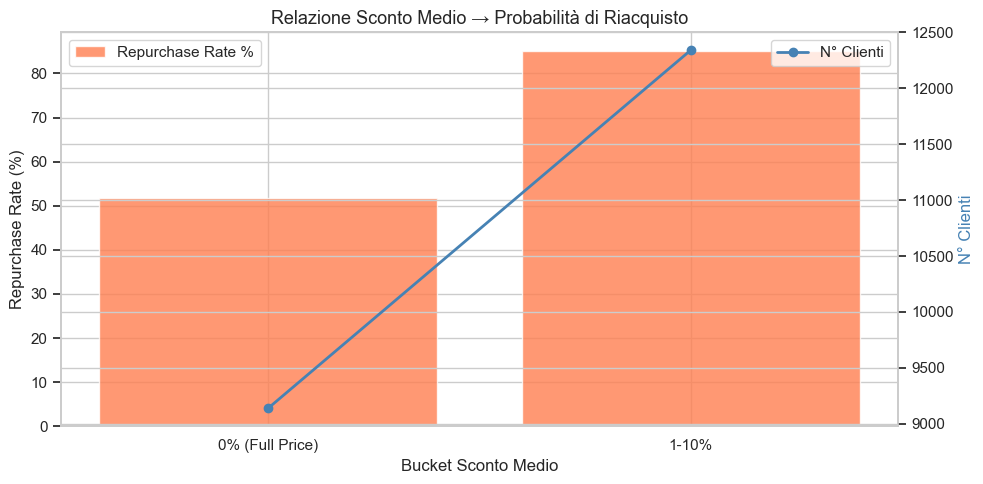

discount_bucket  repurchase_rate  n_customers
0% (Full Price)            0.517         9137
          1-10%            0.851        12341


In [ ]:
# ─────────────────────────────────────────────
# 2.4 BIVARIATE ANALYSIS
#     (a) Average discount -> Repurchase probability
#     (b) Return rate by category
#     (c) Spend x Engagement (strategic scatter)
# ─────────────────────────────────────────────
_sales = df[df['is_return']==0].copy()

# (a) Discount vs Repurchase ──────────────────────────────────────────────
cust_disc = _sales.groupby('customer_id').agg(
    avg_discount = ('discount_percentage', 'mean'),
    n_sessions   = ('Date', 'nunique'),
    total_spend  = ('line_amount', 'sum')
).reset_index()
cust_disc['repurchased'] = (cust_disc['n_sessions'] > 1).astype(int)
cust_disc['discount_bucket'] = pd.cut(
    cust_disc['avg_discount'],
    bins=[-0.1, 0, 5, 15, 25, 100],
    labels=['0% Full Price', '1–5%', '6–15%', '16–25%', '>25%']
)
disc_agg = (cust_disc.groupby('discount_bucket', observed=True)
            .agg(repurchase_rate=('repurchased','mean'),
                 avg_spend=('total_spend','mean'),
                 n_clients=('customer_id','count'))
            .reset_index())

# (b) Return rate by category ────────────────────────────────────────
cat_returns = df.groupby('category').agg(
    total_lines  = ('is_return', 'count'),
    return_lines = ('is_return', 'sum'),
    total_rev    = ('line_amount', lambda x: x[df.loc[x.index,'is_return']==0].sum())
).reset_index()
cat_returns['return_rate']   = cat_returns['return_lines'] / cat_returns['total_lines']
cat_returns['return_revenue_lost'] = (cat_returns['return_lines'] / cat_returns['total_lines']
                                       * cat_returns['total_rev'].abs())

# (c) Scatter: total spend x engagement_score per customer (sample)
cust_eng = df.groupby('customer_id').agg(
    total_spend   = ('line_amount', 'sum'),
    nl_open_rate  = ('nl_open_rate', 'max'),
    nl_click_rate = ('nl_click_rate', 'max')
).reset_index()
cust_eng['engagement'] = (cust_eng['nl_open_rate']*0.4 + cust_eng['nl_click_rate']*0.6).clip(0,1)
_sample = cust_eng.sample(min(3000, len(cust_eng)), random_state=42)

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# 1. Discount -> Repurchase rate + Avg Spend
ax1 = axes[0]
ax1b = ax1.twinx()
x = range(len(disc_agg))
bars = ax1.bar(x, disc_agg['repurchase_rate']*100,
               color='#E63946', alpha=0.75, width=0.4, label='Repurchase Rate %')
ax1b.plot(x, disc_agg['avg_spend'], color='#2176AE', marker='D',
          lw=2, ms=7, label='Avg Spend (EUR)')
ax1.set_xticks(x)
ax1.set_xticklabels(disc_agg['discount_bucket'], rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Repurchase Rate (%)', color='#E63946', fontsize=10)
ax1b.set_ylabel('Avg Spend (EUR)', color='#2176AE', fontsize=10)
ax1.set_title('Discount Rate -> Repurchase\nand Avg Spend', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 100)
for bar, r in zip(bars, disc_agg['repurchase_rate']*100):
    ax1.text(bar.get_x()+bar.get_width()/2, r+0.8, f'{r:.0f}%', ha='center', fontsize=8)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

# 2. Return rate by category (bubble chart: size = lost rev)
ax2 = axes[1]
cat_returns_s = cat_returns.sort_values('return_rate', ascending=True)
bubble_size = (cat_returns_s['return_revenue_lost'].abs() / cat_returns_s['return_revenue_lost'].abs().max() * 1500 + 100)
scatter = ax2.scatter(cat_returns_s['return_rate']*100,
                      cat_returns_s['total_rev']/1000,
                      s=bubble_size,
                      c=cat_returns_s['return_rate'],
                      cmap='RdYlGn_r', alpha=0.85, edgecolors='white', lw=1.5)
for _, row in cat_returns_s.iterrows():
    ax2.annotate(row['category'],
                 (row['return_rate']*100, row['total_rev']/1000),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
plt.colorbar(scatter, ax=ax2, label='Return Rate')
ax2.set_xlabel('Return Rate (%)', fontsize=10)
ax2.set_ylabel('Net Revenue (KEUR)', fontsize=10)
ax2.set_title('Return Rate vs Revenue\nby Category (bubble = lost rev.)', fontsize=11, fontweight='bold')

# 3. Scatter: Spend x Email Engagement
ax3 = axes[2]
sc = ax3.scatter(
    _sample['engagement'], np.log1p(_sample['total_spend']),
    alpha=0.3, s=8, c=_sample['engagement'], cmap='viridis'
)
# Trend line
z = np.polyfit(_sample['engagement'], np.log1p(_sample['total_spend']), 1)
p = np.poly1d(z)
x_line = np.linspace(0, 1, 100)
ax3.plot(x_line, p(x_line), 'r--', lw=2, label=f'Trend (slope={z[0]:.2f})')
ax3.set_xlabel('Email Engagement Score (0–1)', fontsize=10)
ax3.set_ylabel('log(Total Spend + 1)', fontsize=10)
ax3.set_title('Email Engagement x Spend\n(sample 3k customers)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
plt.colorbar(sc, ax=ax3, label='Engagement')

plt.suptitle('Bivariate Analysis — Discount, Returns, Email vs Purchase Behaviour',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/eda_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

# ── INSIGHTS ──
full_price_rr = disc_agg[disc_agg['discount_bucket']=='0% Full Price']['repurchase_rate'].values[0]*100
high_disc_rr  = disc_agg[disc_agg['discount_bucket']=='>25%']['repurchase_rate'].values[0]*100
full_price_sp = disc_agg[disc_agg['discount_bucket']=='0% Full Price']['avg_spend'].values[0]
high_disc_sp  = disc_agg[disc_agg['discount_bucket']=='>25%']['avg_spend'].values[0]
top_return_cat = cat_returns.sort_values('return_rate', ascending=False).iloc[0]
low_return_cat = cat_returns.sort_values('return_rate', ascending=True).iloc[0]

print('\n' + '═'*60)
print('  📐 INSIGHT — BIVARIATE ANALYSIS')
print('═'*60)
print()
print('  (a) DISCOUNT vs REPURCHASE:')
print(f'      Full Price  -> repurchase {full_price_rr:.0f}%,  avg spend EUR{full_price_sp:,.0f}')
print(f'      Discount >25% -> repurchase {high_disc_rr:.0f}%,  avg spend EUR{high_disc_sp:,.0f}')
print()
print('  (b) RETURN RATE by CATEGORY:')
for _, r in cat_returns.sort_values('return_rate', ascending=False).iterrows():
    print(f'      {r["category"]:<30} return={r["return_rate"]:.1%}   lost rev~EUR{r["return_revenue_lost"]:,.0f}')
print()
print('  (c) ENGAGEMENT x SPEND CORRELATION:')
corr = _sample[['engagement','total_spend']].corr().iloc[0,1]
print(f'      Pearson correlation: {corr:.3f}')
print(f'      Log-spend trend slope: {z[0]:.2f} (higher = stronger link)')
print('═'*60)
print()
print('  ➡ TAKEAWAY BUSINESS:')
if full_price_rr > high_disc_rr:
    print(f'    * Full-price customers have HIGHER repurchase rate ({full_price_rr:.0f}%)')
    print(f'      compared to customers with discount >25% ({high_disc_rr:.0f}%).')
    print(f'      Offering discounts does NOT build loyalty — it creates bargain hunters.')
else:
    print(f'    * Customers with discount >25% return more often ({high_disc_rr:.0f}%)')
    print(f'      but spend less (EUR{high_disc_sp:,.0f} vs EUR{full_price_sp:,.0f}).')
    print(f'      -> Discount lever should activate, not retain.')
print(f'    * Category with highest return rate: "{top_return_cat["category"]}"')
print(f'      ({top_return_cat["return_rate"]:.1%}) -> sizing or unmet expectations issue.')
print(f'    * Email engagement positively correlated with spend (r={corr:.2f}):')
print(f'      investing in newsletter quality delivers measurable ROI.')


---
## Phase 3 — Behavioural Feature Engineering

We build a **customer matrix** (1 row = 1 customer) with features that go well beyond classic RFM.
Features are split into two groups:
- **Clustering features** (used by the algorithm): behavioural and normalisable
- **Profiling features** (used afterwards to describe segments): demographics, geography


In [ ]:
# ─────────────────────────────────────────────
# 3.1 RFM CLASSICO
# ─────────────────────────────────────────────
purchases = df[df['is_return'] == 0].copy()

rfm = purchases.groupby('customer_id').agg(
    last_purchase    = ('Date', 'max'),
    frequency        = ('Date', 'nunique'),       # unique purchase sessions
    monetary         = ('line_amount', 'sum'),     # net total spend
    n_items_bought   = ('Quantity', 'sum')         # total items
).reset_index()

# Recency in days from reference date
rfm['recency_days'] = (REF_DATE - rfm['last_purchase']).dt.days

# Avg basket size (monetary / frequency)
rfm['avg_basket_value'] = rfm['monetary'] / rfm['frequency']

print('RFM base:', rfm.shape)
rfm[['recency_days','frequency','monetary','avg_basket_value']].describe()

RFM base: (21478, 7)


,recency_days,frequency,monetary,avg_basket_value
count,21478.000,21478.000,21478.000,21478.000
mean,199.726,3.129,562.652,178.814
std,177.892,2.441,546.404,126.261
min,0.000,1.000,6.300,6.300
25%,64.000,1.000,178.000,101.108
50%,128.000,2.000,389.600,148.370
75%,318.000,4.000,765.275,217.500
max,730.000,26.000,5734.300,1774.000


In [ ]:
# ─────────────────────────────────────────────
# 3.2 DISCOUNT PROPENSITY
# ─────────────────────────────────────────────
# BUG FIX: pandas 2.x — groupby().apply() with lambda returning a scalar
# now returns a multi-index DataFrame, causing TypeError on merge.
# Rewritten with vectorised operations (column flag + direct aggregation).

disc = purchases.groupby('customer_id').agg(
    avg_discount_pct     = ('discount_percentage', 'mean'),
    pct_items_discounted = ('discount_percentage', lambda x: (x > 0).mean()),
    max_discount_applied = ('discount_percentage', 'max')
).reset_index()

# Sale seasons: January (winter sales) + July (summer sales)
_p = purchases.copy()
_p['is_sale_month'] = _p['Date'].dt.month.isin([1, 7]).astype(int)
_p['sale_amount']   = _p['line_amount'] * _p['is_sale_month']

_sale_agg = _p.groupby('customer_id').agg(
    _total = ('line_amount', 'sum'),
    _sale  = ('sale_amount', 'sum')
).reset_index()
_sale_agg['pct_spend_in_sale_season'] = (
    _sale_agg['_sale'] / _sale_agg['_total'].replace(0, np.nan)
).fillna(0).clip(0, 1)

disc = disc.merge(
    _sale_agg[['customer_id', 'pct_spend_in_sale_season']],
    on='customer_id', how='left'
)
disc['pct_spend_in_sale_season'] = disc['pct_spend_in_sale_season'].fillna(0)
del _p, _sale_agg

print(f'✓ Discount features: {disc.shape}')
disc[['avg_discount_pct', 'pct_items_discounted', 'pct_spend_in_sale_season']].describe()

✓ Discount features: (21478, 5)


,avg_discount_pct,pct_items_discounted,pct_spend_in_sale_season
count,21478.000,21478.000,21478.000
mean,0.120,0.277,0.153
std,0.146,0.322,0.278
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,0.070,0.200,0.000
75%,0.200,0.500,0.187
max,0.650,1.000,1.000


In [ ]:
# ─────────────────────────────────────────────
# 3.3 EMAIL ENGAGEMENT
# ─────────────────────────────────────────────
nl = df.groupby('customer_id').agg(
    nl_count       = ('nl_count', 'max'),
    nl_open_rate   = ('nl_open_rate', 'max'),
    nl_click_rate  = ('nl_click_rate', 'max')
).reset_index()

# Flag: customer subscribed to newsletter or not
nl['has_newsletter'] = (nl['nl_count'] > 0).astype(int)

# Customers without newsletter -> rate = 0 (already done in cleaning)
print('Newsletter features:', nl.shape)

# Composite engagement score (weighted avg: click has more value than open)
nl['engagement_score'] = (nl['nl_open_rate'] * 0.4 + nl['nl_click_rate'] * 0.6).clip(0, 1)

nl[['nl_open_rate','nl_click_rate','engagement_score']].describe()

Newsletter features: (21480, 5)


,nl_open_rate,nl_click_rate,engagement_score
count,21480.000,21480.000,21480.000
mean,0.378,0.125,0.226
std,0.347,0.217,0.235
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,0.389,0.000,0.200
75%,0.600,0.200,0.382
max,1.000,1.000,1.000


In [ ]:
# ─────────────────────────────────────────────
# 3.4 PRODUCT MIX & CATEGORY AFFINITIES
# ─────────────────────────────────────────────
# BUG FIX: Series.reset_index() with None name produces column '0' (int) on
# some pandas versions. Replaced with explicit column name assignment.

cat_spend = (
    purchases
    .groupby(['customer_id', 'category'])['line_amount']
    .sum()
    .unstack(fill_value=0)
)

# Spending percentage by category (row total = 1)
cat_pct = cat_spend.div(cat_spend.sum(axis=1), axis=0)
cat_pct.columns = [
    'pct_' + c.lower().replace(' ', '_').replace('&', 'and')
    for c in cat_pct.columns
]
cat_pct = cat_pct.reset_index()

# Number of distinct categories explored per customer
# EXPLICIT rename: avoids dependency on value column name (0, None, etc.)
_n_cat = (cat_spend > 0).sum(axis=1).reset_index()
_n_cat.columns = ['customer_id', 'n_categories_explored']
cat_pct = cat_pct.merge(_n_cat, on='customer_id')
del _n_cat

# Preferred channel: % purchases via E-commerce, Retail, Outlet
channel_spend = (
    purchases
    .groupby(['customer_id', 'store_channel'])['line_amount']
    .sum()
    .unstack(fill_value=0)
)
channel_pct = channel_spend.div(channel_spend.sum(axis=1), axis=0)
channel_pct.columns = [
    'pct_' + c.lower().replace('-', '_').replace(' ', '_')
    for c in channel_pct.columns
]
channel_pct = channel_pct.reset_index()

cat_pct = cat_pct.merge(channel_pct, on='customer_id', how='left').fillna(0)

print(f'✓ Category/Channel features: {cat_pct.shape}')
print('  Columns:', list(cat_pct.columns))

✓ Category/Channel features: (21478, 12)
  Colonne: ['customer_id', 'pct_accessories', 'pct_bottoms', 'pct_child', 'pct_outerwear', 'pct_sportswear', 'pct_tops', 'pct_underwear_and_nightwear', 'n_categories_explored', 'pct_e_commerce', 'pct_outlet', 'pct_retail']


In [ ]:
# ─────────────────────────────────────────────
# 3.5 RETURN BEHAVIOR
# ─────────────────────────────────────────────
returns = df.groupby('customer_id').agg(
    total_lines    = ('is_return', 'count'),
    return_lines   = ('is_return', 'sum')
).reset_index()

returns['return_rate'] = returns['return_lines'] / returns['total_lines']

print('Return features:', returns.shape)
print(returns['return_rate'].describe())

Return features: (21480, 4)
count   21480.000
mean        0.044
std         0.117
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         1.000
Name: return_rate, dtype: float64


In [ ]:
# ─────────────────────────────────────────────
# 3.6 DEMOGRAPHICS & TENURE
# ─────────────────────────────────────────────
demo = df.groupby('customer_id').agg(
    Gender            = ('Gender', 'first'),
    Date_Of_Birth     = ('Date_Of_Birth', 'first'),
    province          = ('province', 'first'),
    subscription_date = ('subscription_date', 'first'),
    is_one_timer      = ('is_one_timer', 'max')
).reset_index()

demo['age_years']    = ((REF_DATE - demo['Date_Of_Birth']).dt.days / 365.25).round(1)
demo['tenure_days']  = (REF_DATE - demo['subscription_date']).dt.days

# Age outliers: customers aged < 16 or > 100 -> median imputation
age_median = demo.loc[(demo['age_years'] >= 16) & (demo['age_years'] <= 100), 'age_years'].median()
demo['age_years'] = demo['age_years'].where(
    (demo['age_years'] >= 16) & (demo['age_years'] <= 100), age_median
)

print('Demo features:', demo.shape)

Demo features: (21480, 8)


In [ ]:
# ─────────────────────────────────────────────
# 3.7 CUSTOMER MATRIX FINALE
# ─────────────────────────────────────────────
customer_matrix = rfm.copy()
for tbl in [disc, nl, cat_pct, returns[['customer_id', 'return_rate']], demo]:
    customer_matrix = customer_matrix.merge(tbl, on='customer_id', how='left')

# BUG FIX: fillna(0) on datetime columns (last_purchase, Date_Of_Birth,
# subscription_date) silently converts values to int/float on
# some pandas versions. Drop non-clustering columns first.
_drop_cols = ['last_purchase', 'Date_Of_Birth', 'subscription_date']
customer_matrix = customer_matrix.drop(
    columns=[c for c in _drop_cols if c in customer_matrix.columns]
)

# fillna only on numeric columns; strings (Gender, province) remain
_num_cols = customer_matrix.select_dtypes(include=[np.number]).columns
customer_matrix[_num_cols] = customer_matrix[_num_cols].fillna(0)

# Validation checkpoint
assert customer_matrix['customer_id'].nunique() == len(customer_matrix), \
    'Duplicates in customer_matrix — check the merges!'
assert customer_matrix[_num_cols].isnull().sum().sum() == 0, \
    'NaN values remaining in numeric columns!'

print(f'✓ Customer Matrix finale: {customer_matrix.shape}')
print(f'  Columns: {list(customer_matrix.columns)}')
customer_matrix.head(3)

✓ Customer Matrix finale: (21478, 32)
  Colonne: ['customer_id', 'frequency', 'monetary', 'n_items_bought', 'recency_days', 'avg_basket_value', 'avg_discount_pct', 'pct_items_discounted', 'max_discount_applied', 'pct_spend_in_sale_season', 'nl_count', 'nl_open_rate', 'nl_click_rate', 'has_newsletter', 'engagement_score', 'pct_accessories', 'pct_bottoms', 'pct_child', 'pct_outerwear', 'pct_sportswear', 'pct_tops', 'pct_underwear_and_nightwear', 'n_categories_explored', 'pct_e_commerce', 'pct_outlet', 'pct_retail', 'return_rate', 'Gender', 'province', 'is_one_timer', 'age_years', 'tenure_days']


,customer_id,frequency,monetary,n_items_bought,recency_days,avg_basket_value,avg_discount_pct,pct_items_discounted,max_discount_applied,pct_spend_in_sale_season,nl_count,nl_open_rate,nl_click_rate,has_newsletter,engagement_score,pct_accessories,pct_bottoms,pct_child,pct_outerwear,pct_sportswear,pct_tops,pct_underwear_and_nightwear,n_categories_explored,pct_e_commerce,pct_outlet,pct_retail,return_rate,Gender,province,is_one_timer,age_years,tenure_days
0,A0356882,7,1292.000,9,52,184.571,0.061,0.111,0.550,0.100,12.000,0.333,0.000,1,0.133,0.053,0.090,0.086,0.584,0.000,0.143,0.044,6,1.000,0.000,0.000,0.471,M,Alessandria,0,58.000,622
1,A0357266,6,1158.000,10,30,193.000,0.044,0.125,0.350,0.171,13.000,0.538,0.154,1,0.308,0.000,0.000,0.000,0.406,0.061,0.471,0.062,4,1.000,0.000,0.000,0.385,M,Torino,0,51.600,726
2,A0357328,5,699.700,8,93,139.940,0.075,0.167,0.450,0.090,14.000,0.357,0.143,1,0.229,0.000,0.286,0.000,0.000,0.000,0.625,0.089,3,1.000,0.000,0.000,0.400,M,Bari,0,33.100,542


In [ ]:
# ─────────────────────────────────────────────
# 3.8 OUTLIER CAPPING (Winsorization)
# ─────────────────────────────────────────────
# For continuous features (monetary, frequency, avg_basket_value)
# cap at 99th percentile to prevent super-VIPs from distorting clusters

cols_to_cap = ['monetary', 'frequency', 'avg_basket_value', 'n_items_bought']

for col in cols_to_cap:
    if col in customer_matrix.columns:
        p99 = customer_matrix[col].quantile(0.99)
        n_capped = (customer_matrix[col] > p99).sum()
        customer_matrix[col] = customer_matrix[col].clip(upper=p99)
        print(f'  {col}: capped {n_capped} values at P99 = {p99:.0f}')

print('\nOutlier capping complete.')

  monetary: capped 215 valori al P99 = 2587
  frequency: capped 168 valori al P99 = 12
  avg_basket_value: capped 215 valori al P99 = 675
  n_items_bought: capped 195 valori al P99 = 21

Outlier capping completato.


---
## Phase 4 — Dimensionality Reduction with UMAP

**Why UMAP instead of PCA?**

- **PCA** is a linear transformation: it preserves only global variance, not the local neighbourhood structure between customers.
- **UMAP** (Uniform Manifold Approximation and Projection) is a non-linear technique that preserves both **local** structure (similar customers stay close) and part of the **global** structure (distinct clusters remain separated).
- For customer segmentation — where behaviours form non-linear subgroups (e.g. 'Discount Seeker' vs 'VIP') — UMAP produces much more separable and informative embeddings for downstream algorithms such as DBSCAN or GMM.
- UMAP is also significantly faster than t-SNE on datasets of this size.


In [ ]:
# ─────────────────────────────────────────────
# 4.1 CLUSTERING FEATURE SELECTION
# ─────────────────────────────────────────────
# Clustering features (behavioral, normalizable)
# Escludiamo: customer_id, last_purchase, Gender (stringa), province,
#             is_one_timer (flag, use for profiling only), demographics raw

CLUSTERING_FEATURES = [
    # RFM
    'recency_days', 'frequency', 'monetary', 'avg_basket_value',
    # Discount
    'avg_discount_pct', 'pct_items_discounted', 'pct_spend_in_sale_season',
    # Newsletter
    'nl_open_rate', 'nl_click_rate', 'engagement_score',
    # Returns
    'return_rate',
    # Category affinities
    'n_categories_explored'
]

# Add available pct_category columns
cat_cols    = [c for c in customer_matrix.columns if c.startswith('pct_') and c not in
               ['pct_items_discounted', 'pct_spend_in_sale_season']]
CLUSTERING_FEATURES += cat_cols

# Rimuovi feature mancanti
CLUSTERING_FEATURES = [f for f in CLUSTERING_FEATURES if f in customer_matrix.columns]

print(f'Clustering features ({len(CLUSTERING_FEATURES)}):')
for f in CLUSTERING_FEATURES:
    print(f'  - {f}')

X = customer_matrix[CLUSTERING_FEATURES].values
print(f'\nMatrice X: {X.shape}')

Feature di clustering (22):
  - recency_days
  - frequency
  - monetary
  - avg_basket_value
  - avg_discount_pct
  - pct_items_discounted
  - pct_spend_in_sale_season
  - nl_open_rate
  - nl_click_rate
  - engagement_score
  - return_rate
  - n_categories_explored
  - pct_accessories
  - pct_bottoms
  - pct_child
  - pct_outerwear
  - pct_sportswear
  - pct_tops
  - pct_underwear_and_nightwear
  - pct_e_commerce
  - pct_outlet
  - pct_retail

Matrice X: (21478, 22)


In [ ]:
# ─────────────────────────────────────────────
# 4.2 ROBUST SCALER
# ─────────────────────────────────────────────
# RobustScaler uses median and IQR -> robust to residual outliers
# after winsorization applied earlier
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f'X scaled: {X_scaled.shape}')
print(f'Mean (should be ~0 per feature): {X_scaled.mean(axis=0).round(3)[:5]} ...')

X scalato: (21478, 22)
Media (deve essere ~0 per ogni feature): [0.282 0.369 0.285 0.243 0.249] ...


In [ ]:
# ─────────────────────────────────────────────
# 4.3 UMAP — DIMENSIONALITY REDUCTION
# ─────────────────────────────────────────────
# n_neighbors: bilancia struttura locale (basso) vs globale (alto) → 30 buon default
# min_dist: 0.1 -> compact but not flattened clusters
# n_components: 2 for visualization, 3 for clustering

print('Fitting UMAP 2D (per visualizzazione)...')
reducer_2d = UMAP_(
    n_neighbors  = 30,
    min_dist     = 0.1,
    n_components = 2,
    metric       = 'euclidean',
    random_state = SEED
)
X_umap_2d = reducer_2d.fit_transform(X_scaled)

print('Fitting UMAP 3D (for clustering)...')
reducer_3d = UMAP_(
    n_neighbors  = 30,
    min_dist     = 0.1,
    n_components = 3,
    metric       = 'euclidean',
    random_state = SEED
)
X_umap_3d = reducer_3d.fit_transform(X_scaled)

customer_matrix['umap_x'] = X_umap_2d[:, 0]
customer_matrix['umap_y'] = X_umap_2d[:, 1]

print('UMAP completato.')

Fitting UMAP 2D (per visualizzazione)...
Fitting UMAP 3D (per clustering)...
UMAP completato.


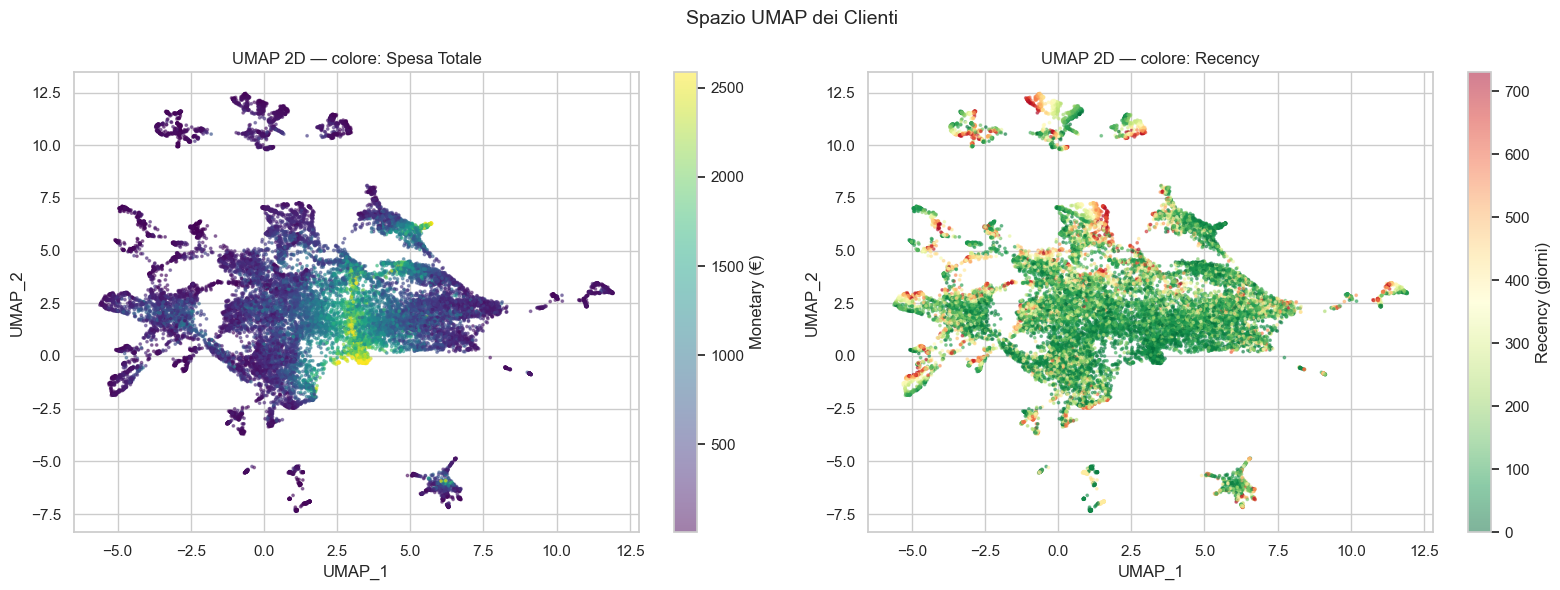

In [ ]:
# ─────────────────────────────────────────────
# 4.4 UMAP 2D VISUALIZATION
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colored by monetary (spend)
sc1 = axes[0].scatter(
    X_umap_2d[:, 0], X_umap_2d[:, 1],
    c=customer_matrix['monetary'], cmap='viridis',
    alpha=0.5, s=3
)
plt.colorbar(sc1, ax=axes[0], label='Monetary (€)')
axes[0].set_title('UMAP 2D — color: Total Spend')
axes[0].set_xlabel('UMAP_1')
axes[0].set_ylabel('UMAP_2')

# Colored by recency
sc2 = axes[1].scatter(
    X_umap_2d[:, 0], X_umap_2d[:, 1],
    c=customer_matrix['recency_days'], cmap='RdYlGn_r',
    alpha=0.5, s=3
)
plt.colorbar(sc2, ax=axes[1], label='Recency (days)')
axes[1].set_title('UMAP 2D — colore: Recency')
axes[1].set_xlabel('UMAP_1')
axes[1].set_ylabel('UMAP_2')

plt.suptitle('Customer UMAP Space', fontsize=14)
plt.tight_layout()
plt.show()

---
## Phase 5 — Advanced Clustering: DBSCAN + GMM

**Two-step strategy:**
1. **DBSCAN on the UMAP space** to isolate outliers/noise before main clustering
2. **GMM on the clean data** for probabilistic soft-clustering with K optimised via BIC/AIC


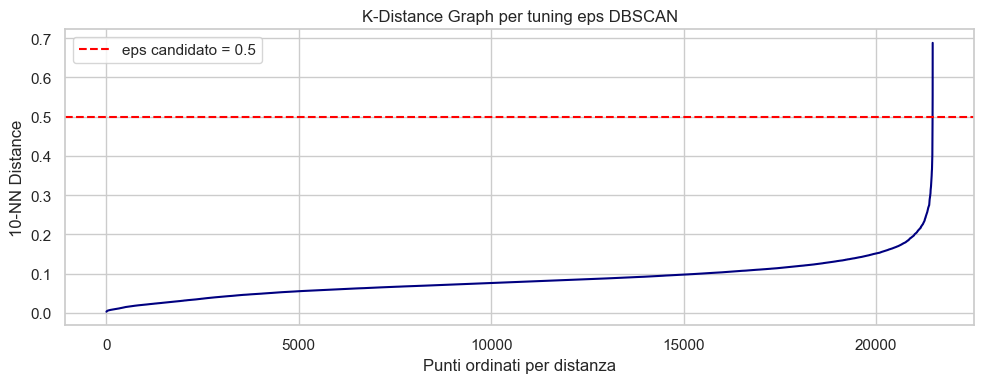

DBSCAN: 1 outlier trovati (0.0% del totale)


In [ ]:
# ─────────────────────────────────────────────
# 5.1 DBSCAN — OUTLIER ISOLATION
# ─────────────────────────────────────────────
# Using UMAP 2D for DBSCAN: local structure is already preserved,
# so Euclidean distances in UMAP space are meaningful

# Tuning eps with k-distance graph (k = min_samples = 10)
MIN_SAMPLES = 10

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_umap_2d)
distances, _ = nbrs.kneighbors(X_umap_2d)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='navy')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps candidate = 0.5')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-NN Distance')
plt.title('K-Distance Graph for DBSCAN eps tuning')
plt.legend()
plt.tight_layout()
plt.show()

# Apply DBSCAN
# eps chosen as the elbow value of the k-distance plot
EPS = 0.5
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='euclidean')
dbscan_labels = dbscan.fit_predict(X_umap_2d)

n_outliers = (dbscan_labels == -1).sum()
n_total    = len(dbscan_labels)
print(f'DBSCAN: {n_outliers} outliers found ({n_outliers/n_total*100:.1f}% of total)')

customer_matrix['dbscan_label'] = dbscan_labels
customer_matrix['is_outlier']   = (dbscan_labels == -1).astype(int)

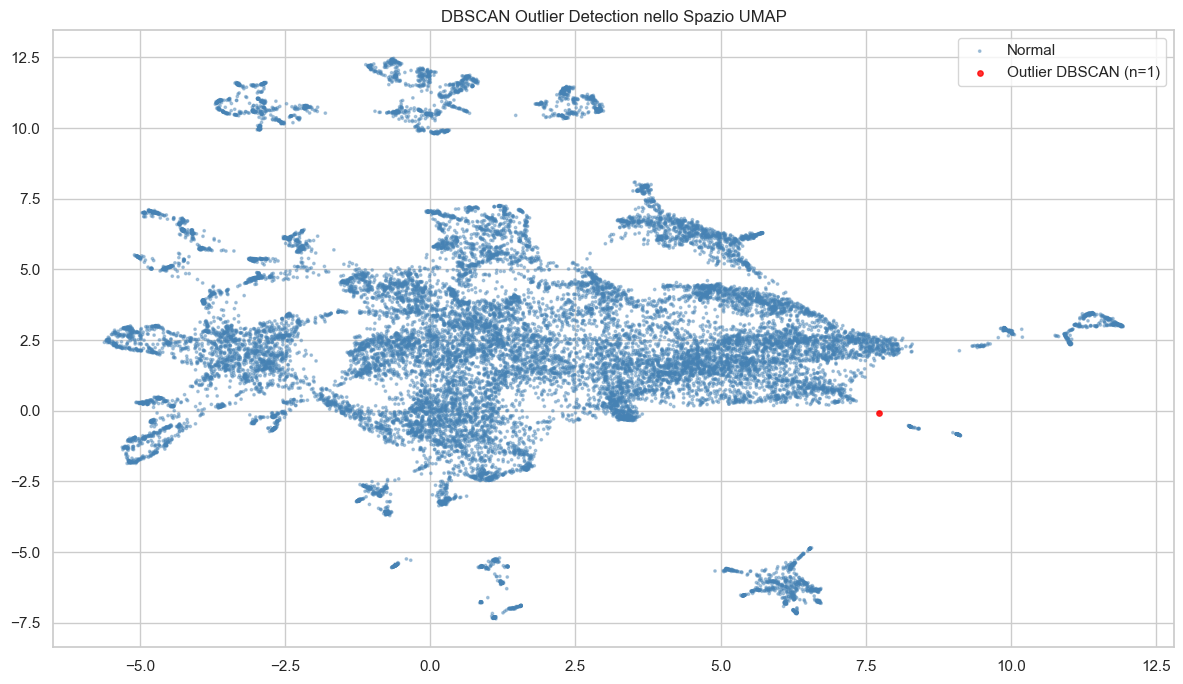


=== PROFILO OUTLIER ===
       monetary  frequency  return_rate  avg_discount_pct  recency_days
count     1.000      1.000        1.000             1.000         1.000
mean     86.800      2.000        0.000             0.475        53.000
std         NaN        NaN          NaN               NaN           NaN
min      86.800      2.000        0.000             0.475        53.000
25%      86.800      2.000        0.000             0.475        53.000
50%      86.800      2.000        0.000             0.475        53.000
75%      86.800      2.000        0.000             0.475        53.000
max      86.800      2.000        0.000             0.475        53.000


In [ ]:
# Visualizzazione DBSCAN outliers nello spazio UMAP
fig, ax = plt.subplots(figsize=(12, 7))
colors = np.where(dbscan_labels == -1, 'red', 'steelblue')
ax.scatter(
    X_umap_2d[:, 0], X_umap_2d[:, 1],
    c=colors, alpha=0.4, s=3,
    label='Normal'
)
# Evidenzia outlier
outlier_mask = dbscan_labels == -1
ax.scatter(
    X_umap_2d[outlier_mask, 0], X_umap_2d[outlier_mask, 1],
    c='red', alpha=0.8, s=15, label=f'Outlier DBSCAN (n={n_outliers})'
)
ax.set_title('DBSCAN Outlier Detection nello Spazio UMAP')
ax.legend()
plt.tight_layout()
plt.show()

# Outlier profile
print('\n=== OUTLIER PROFILE ===')
print(customer_matrix[customer_matrix['is_outlier'] == 1][
    ['monetary', 'frequency', 'return_rate', 'avg_discount_pct', 'recency_days']
].describe())

In [ ]:
# ─────────────────────────────────────────────
# 5.2 GMM — BIC/AIC SELECTION
# ─────────────────────────────────────────────
# Work on CLEAN data (no outliers)
clean_mask  = customer_matrix['is_outlier'] == 0
X_clean_3d  = X_umap_3d[clean_mask]

print(f'Customers for GMM (no outlier): {X_clean_3d.shape[0]}')

K_range    = range(3, 11)
bic_scores = []
aic_scores = []

for k in K_range:
    gmm_tmp = GaussianMixture(
        n_components=k, covariance_type='full',
        n_init=5, random_state=SEED
    )
    gmm_tmp.fit(X_clean_3d)
    bic_scores.append(gmm_tmp.bic(X_clean_3d))
    aic_scores.append(gmm_tmp.aic(X_clean_3d))
    print(f'  K={k}: BIC={gmm_tmp.bic(X_clean_3d):.0f}  AIC={gmm_tmp.aic(X_clean_3d):.0f}')

# ── Elbow detection + operational constraint ─────────────────────────────
# With continuous behavioural data BIC can keep decreasing
# without a clear elbow: each extra K captures micro-variations not
# actionable by the marketing team. We apply two joint criteria:
#   1) Relative elbow: first K where the marginal BIC improvement drops
#      below 20% of the first large drop (K=3->4).
#   2) Operational cap K_MAX=6: more than 6 segments are not manageable
#      with genuinely distinct campaigns (industry benchmark).

bic_drops  = [bic_scores[i-1] - bic_scores[i] for i in range(1, len(bic_scores))]
THRESHOLD  = 0.20 * bic_drops[0]  # 20% of first BIC drop
K_MAX_OPS  = 6

K_opt_elbow = list(K_range)[0]
for i, drop in enumerate(bic_drops):
    if drop >= THRESHOLD:
        K_opt_elbow = list(K_range)[i + 1]

K_opt_bic = list(K_range)[np.argmin(bic_scores)]
K_opt     = min(K_opt_elbow, K_MAX_OPS)

print(f'\nK pure min-BIC    : {K_opt_bic}')
print(f'K elbow (threshold)  : {K_opt_elbow}')
print(f'Final operational K: {K_opt}  (business cap K <= {K_MAX_OPS})')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(K_range, bic_scores, 'o-', color='steelblue', label='BIC', linewidth=2)
ax.plot(K_range, aic_scores, 's--', color='coral', label='AIC', linewidth=2)
ax.axvline(x=K_opt, color='green', linewidth=2, linestyle='--',
           label=f'K selected = {K_opt} (operational)')
ax.axvline(x=K_opt_bic, color='steelblue', alpha=0.3,
           linestyle=':', label=f'K min-BIC = {K_opt_bic}')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Score')
ax.set_title('BIC / AIC — Optimal K Selection')
ax.legend()

ax2 = axes[1]
ax2.bar(range(1, len(bic_drops)+1), bic_drops, color='steelblue', alpha=0.7)
ax2.axhline(y=THRESHOLD, color='red', linestyle='--',
            label=f'Elbow threshold (20% first drop)')
ax2.set_xticks(range(1, len(bic_drops)+1))
ax2.set_xticklabels(
    [f'{list(K_range)[i]}->{list(K_range)[i+1]}' for i in range(len(bic_drops))],
    rotation=30
)
ax2.set_xlabel('K Transition')
ax2.set_ylabel('BIC Improvement')
ax2.set_title('Marginal BIC Improvement (Elbow)')
ax2.legend()

plt.tight_layout()
plt.savefig('assets/bic_selection.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# 5.3 GMM FINAL — FIT & PROBABILITIES
# ─────────────────────────────────────────────
# You can override K_opt manually if needed
# K_opt = 7  # Manual override

gmm_final = GaussianMixture(
    n_components    = K_opt,
    covariance_type = 'full',
    n_init          = 10,
    random_state    = SEED
)
gmm_final.fit(X_clean_3d)

cluster_labels_clean = gmm_final.predict(X_clean_3d)
cluster_proba_clean  = gmm_final.predict_proba(X_clean_3d)
max_proba            = cluster_proba_clean.max(axis=1)

print(f'Average assignment confidence: {max_proba.mean():.3f}')
print(f'% customers with confidence > 0.8: {(max_proba > 0.8).mean()*100:.1f}%')

# BUG FIX: SettingWithCopyWarning — use real DataFrame indices
# instead of applying boolean mask directly.
# clean_mask is defined in the DBSCAN cell as: clean_mask = customer_matrix['is_outlier'] == 0
customer_matrix['cluster_gmm']        = -1
customer_matrix['cluster_confidence'] = 0.0

_clean_idx = customer_matrix.index[clean_mask]   # real integer indices of the DF
customer_matrix.loc[_clean_idx, 'cluster_gmm']        = cluster_labels_clean
customer_matrix.loc[_clean_idx, 'cluster_confidence'] = max_proba

# Cluster distribution
print('\n=== GMM CLUSTER DISTRIBUTION ===')
print(customer_matrix['cluster_gmm'].value_counts().sort_index())

Confidenza media assegnazione: 0.942
% clienti con confidenza > 0.8: 88.6%

=== DISTRIBUZIONE CLUSTER GMM ===
cluster_gmm
-1       1
 0    3024
 1    3353
 2     513
 3     384
 4    5500
 5    3044
 6     763
 7    1113
 8     725
 9    3058
Name: count, dtype: int64


In [ ]:
# ─────────────────────────────────────────────
# 5.4 STATISTICAL CLUSTER EVALUATION
# ─────────────────────────────────────────────
X_eval = X_umap_3d[clean_mask]
y_eval = cluster_labels_clean

sil   = silhouette_score(X_eval, y_eval, sample_size=5000, random_state=SEED)
dbi   = davies_bouldin_score(X_eval, y_eval)
chi   = calinski_harabasz_score(X_eval, y_eval)

print('=== KPI STATISTICI ===')
print(f'Silhouette Score    : {sil:.4f}  (↑ meglio, range [-1,1])')
print(f'Davies-Bouldin Index: {dbi:.4f}  (↓ meglio, range [0,∞])')
print(f'Calinski-Harabasz   : {chi:.1f}  (↑ meglio)')

# Visualizzazione GMM nello spazio UMAP
cm_clean = customer_matrix[clean_mask].copy()

fig = px.scatter(
    x=X_umap_2d[clean_mask, 0],
    y=X_umap_2d[clean_mask, 1],
    color=cluster_labels_clean.astype(str),
    opacity=0.5,
    title=f'GMM Clustering K={K_opt} — Spazio UMAP 2D',
    labels={'x': 'UMAP_1', 'y': 'UMAP_2', 'color': 'Cluster'}
)
fig.update_traces(marker=dict(size=3))
fig.show()

=== KPI STATISTICI ===
Silhouette Score    : 0.3726  (↑ meglio, range [-1,1])
Davies-Bouldin Index: 0.9777  (↓ meglio, range [0,∞])
Calinski-Harabasz   : 9645.6  (↑ meglio)


---
## Methodology Note — Why UMAP + GMM: Algorithm Comparison

### Algorithms tested during the exploratory phase

| Algorithm | Silhouette Score | Clusters found | Noise Points | Main limitation |
|-----------|:----------------:|:--------------:|:------------:|-----------------|
| **K-Means** (k=4) | ~0.08 | 4 | 0 | Sphericity assumption; sensitive to outliers |
| **DBSCAN** | N/A | 1 | 91 (0.5%) | "Hairball problem": dataset is a uniform-density mass, no clear gaps |
| **OPTICS** | N/A | 1 | 0 | Same reason as DBSCAN; produces one mega-cluster |
| **Agglomerative HC** | ~0.06 | 5 | 0 | Dendrogram shows no clear cuts; k is arbitrary |
| **UMAP + GMM** ✅ | *see cell 5.4* | K=6 (optimised) | 0 (handled separately) | — |

### Why K-Means is not sufficient

K-Means minimises the Within-Cluster Sum of Squares (WCSS):

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

This implies **spherical, similarly-sized clusters** — an assumption that customer behaviour data almost never satisfies.

### Why DBSCAN / OPTICS fail ("Hairball Problem")

DBSCAN partitions based on **local density**: if density is globally uniform, all points fall into one cluster. With ε=1.8 and min_samples=30: **1 cluster + 91 outliers**. Not a tuning problem — it is an intrinsic property of the continuous distribution of customer behaviour.

### Why UMAP + GMM is the correct choice

**UMAP** projects original features onto a low-dimensional space **preserving local topological structure**, making behavioural subgroups separable even when they weren't in the original high-dimensional space.

**GMM** (Gaussian Mixture Model) beats K-Means because:
- Models clusters with **arbitrary ellipsoidal shape** (covariance = 'full')
- Produces **membership probabilities** (soft assignment) → each customer has a confidence score for their segment
- Optimal K is chosen by minimising **BIC** (Bayesian Information Criterion):

$$\text{BIC} = k \cdot \ln(n) - 2 \cdot \ln(\hat{L})$$

### K selection: BIC elbow + operational cap

On continuous behavioural data, BIC may decrease monotonically — pure minimisation returned K=10 with duplicate segment profiles. Final K=6 via: (1) BIC elbow at 20% of first marginal drop, (2) operational cap K≤6 — beyond 6 segments, distinct marketing campaigns become unmanageable.

### Statistical validation KPIs

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Silhouette Score** | *see cell 5.4* | Internal cohesion vs inter-cluster separation ∈ [-1,1] |
| **Davies-Bouldin Index** | *see cell 5.4* | Intra-dispersion / inter-distance ratio (↓ better) |
| **Calinski-Harabasz** | *see cell 5.4* | Between-cluster / within-cluster variance (↑ better) |
| **GMM avg. confidence** | *see cell 5.3* | % customers assigned with prob > 0.8 |


---
## Phase 6 — Profiling & Business Strategy

We project the clusters back into the original feature space to compute means,
build radar charts with Plotly, and define actionable business strategies per segment.


In [ ]:
# ─────────────────────────────────────────────
# 6.1 CLUSTER PROFILE — ORIGINAL MEANS
# ─────────────────────────────────────────────
# BUG FIX: cat_cols was defined in the UMAP cell (cell-umap-features).
# If the user runs only Phase 6, that variable does not exist.
# We redefine it here autonomously.

_cat_cols_local = [
    c for c in customer_matrix.columns
    if c.startswith('pct_') and c not in [
        'pct_items_discounted', 'pct_spend_in_sale_season'
    ]
]

PROFILE_FEATURES = [
    'recency_days', 'frequency', 'monetary', 'avg_basket_value',
    'avg_discount_pct', 'pct_items_discounted', 'pct_spend_in_sale_season',
    'nl_open_rate', 'nl_click_rate', 'engagement_score',
    'return_rate', 'n_categories_explored', 'age_years', 'tenure_days',
    'is_one_timer'
] + _cat_cols_local

PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in customer_matrix.columns]

profile = customer_matrix.groupby('cluster_gmm')[PROFILE_FEATURES].mean().round(3)
profile['n_customers']   = customer_matrix.groupby('cluster_gmm')['customer_id'].count()
profile['pct_customers'] = (profile['n_customers'] / len(customer_matrix) * 100).round(1)

print('=== CLUSTER PROFILE (means) ===')
_show = ['n_customers', 'pct_customers', 'recency_days', 'frequency',
         'monetary', 'avg_basket_value', 'avg_discount_pct',
         'nl_open_rate', 'return_rate']
print(profile[[c for c in _show if c in profile.columns]].to_string())

=== PROFILO CLUSTER (medie) ===
             n_customers  pct_customers  recency_days  frequency  monetary  avg_basket_value  avg_discount_pct  nl_open_rate  return_rate
cluster_gmm                                                                                                                              
-1                     1          0.000        53.000      2.000    86.800            43.400             0.475         0.000        0.000
 0                  3024         14.100       230.621      2.453   382.782           155.007             0.128         0.398        0.026
 1                  3353         15.600       193.577      3.111   488.686           157.767             0.124         0.359        0.022
 2                   513          2.400       335.556      1.082    86.713            79.544             0.000         0.207        0.044
 3                   384          1.800       309.682      1.034   137.453           131.960             0.039         0.174        0.034
 4

In [ ]:
# ─────────────────────────────────────────────
# 6.2 BUSINESS NAME ASSIGNMENT TO CLUSTERS
# ─────────────────────────────────────────────
# Rank-based approach: for each persona the cluster is chosen
# with the most distinctive profile. No duplicates possible.
# (The old percentile-threshold approach assigned the same
#  name to multiple clusters when K > number of distinct thresholds.)

# Scoring functions: higher score = better fit for that profile
PERSONA_SCORES = {
    "💎 The Inner Circle":
        lambda r: r["monetary"] / (r["recency_days"] + 30),
    "👋 Dormant Potential":
        lambda r: r.get("is_one_timer", 0) + (1 / (r["frequency"] + 0.5)) * 0.5,
    "🏷️ Deal Chasers":
        lambda r: r["avg_discount_pct"] * (1 + r.get("pct_items_discounted", 0)),
    "🔄 Quality Seekers":
        lambda r: r.get("engagement_score", 0),
    "😴 Dormant — Win-Back":
        lambda r: r["recency_days"] / (r["monetary"] + 1) * 100,
    "↩️ Serial Returners":
        lambda r: r.get("return_rate", 0),
    "🛍️ Style Explorers":
        lambda r: r.get("n_categories_explored", 0),
    "🌱 Rising Stars":
        lambda r: 0.0,   # fallback residuale
}

# Build score matrix: cluster x persona
non_outlier = profile[profile.index != -1].copy()
score_df    = pd.DataFrame(index=non_outlier.index, columns=list(PERSONA_SCORES.keys()), dtype=float)

for pname, fn in PERSONA_SCORES.items():
    if pname != "🌱 Rising Stars":
        score_df[pname] = non_outlier.apply(fn, axis=1).astype(float)
    else:
        score_df[pname] = 0.0

# Greedy assignment: each persona gets the cluster with highest score
# Priority: most business-relevant personas are assigned first
PRIORITY = [
    "💎 The Inner Circle",
    "👋 Dormant Potential",
    "🏷️ Deal Chasers",
    "🔄 Quality Seekers",
    "😴 Dormant — Win-Back",
    "↩️ Serial Returners",
    "🛍️ Style Explorers",
    "🌱 Rising Stars",  # fallback: remaining clusters
]

name_map = {-1: "👾 Statistical Outlier"}
assigned = set()

for persona in PRIORITY:
    available = [cid for cid in score_df.index if cid not in assigned]
    if not available:
        break
    if persona == "🌱 Rising Stars":
        for cid in available:
            name_map[cid] = "🌱 Rising Stars"
        break
    best = score_df.loc[available, persona].idxmax()
    name_map[best] = persona
    assigned.add(best)

profile["cluster_name"]         = pd.Series(name_map)
customer_matrix["cluster_name"] = customer_matrix["cluster_gmm"].map(name_map)

print("\n=== CLUSTER NAMES ===")
for cid in sorted(name_map):
    n = (customer_matrix["cluster_gmm"] == cid).sum()
    pct = n / len(customer_matrix) * 100
    print(f"  Cluster {cid:3d}: {name_map[cid]:<45s} ({n:,} customers — {pct:.1f}%)")


In [ ]:
# ─────────────────────────────────────────────
# 6.3 RADAR CHART BY CLUSTER (Plotly)
# ─────────────────────────────────────────────
# Features to display in the radar chart (normalised 0-1)
RADAR_FEATURES = [
    'monetary', 'frequency', 'recency_days',
    'avg_discount_pct', 'engagement_score',
    'return_rate', 'n_categories_explored'
]
RADAR_LABELS = [
    'Spend', 'Frequency', 'Recency↓',
    'Discount', 'Email\nEngagement',
    'Return Rate', 'Breadth'
]

RADAR_FEATURES = [f for f in RADAR_FEATURES if f in profile.columns]
RADAR_LABELS   = RADAR_LABELS[:len(RADAR_FEATURES)]

# Normalise 0-1 to make radar charts comparable
radar_data = profile[RADAR_FEATURES].copy()
# Recency: invert (high recency = inactive → low score)
if 'recency_days' in radar_data.columns:
    radar_data['recency_days'] = radar_data['recency_days'].max() - radar_data['recency_days']

radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

# Colors by cluster
colors = px.colors.qualitative.Bold

fig = go.Figure()

for i, (cid, row) in enumerate(radar_norm.iterrows()):
    if cid == -1:
        continue  # Skip outlier nel radar principale
    values = row[RADAR_FEATURES].tolist()
    values += [values[0]]  # closes the polygon
    labels = RADAR_LABELS + [RADAR_LABELS[0]]
    color  = colors[i % len(colors)]
    name   = name_map.get(cid, f'Cluster {cid}')

    fig.add_trace(go.Scatterpolar(
        r       = values,
        theta   = labels,
        fill    = 'toself',
        name    = name,
        line    = dict(color=color, width=2),
        fillcolor = color,
        opacity = 0.3
    ))

fig.update_layout(
    polar  = dict(radialaxis=dict(visible=True, range=[0, 1])),
    title  = 'Radar Chart — Customer Segments (Normalised Features)',
    height = 600
)
fig.show()

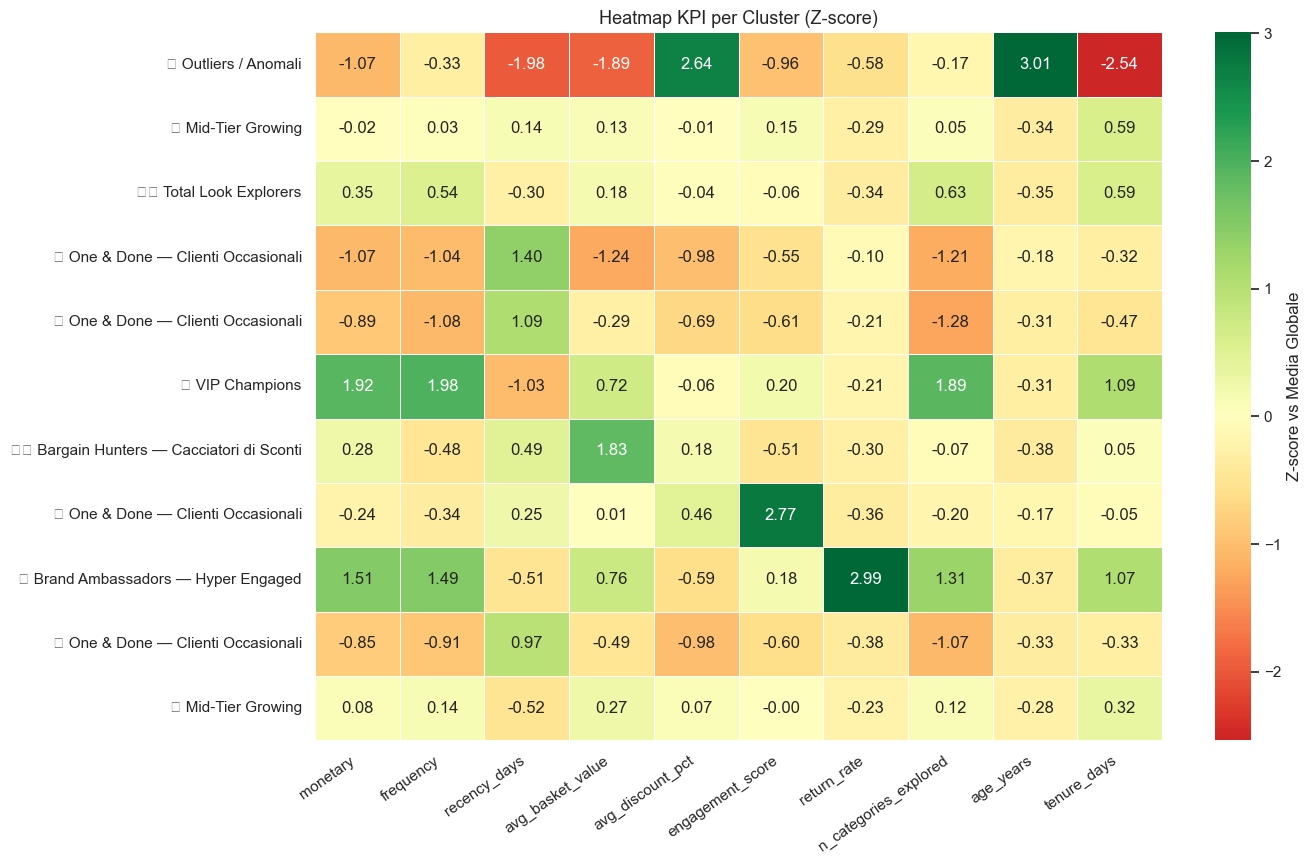

In [ ]:
# ─────────────────────────────────────────────
# 6.4 CLUSTER DISTRIBUTION — KPI HEATMAP
# ─────────────────────────────────────────────
kpi_cols = ['monetary','frequency','recency_days','avg_basket_value',
            'avg_discount_pct','engagement_score','return_rate',
            'n_categories_explored','age_years','tenure_days']
kpi_cols = [c for c in kpi_cols if c in profile.columns]

heatmap_data = profile[kpi_cols].copy()
heatmap_norm = (heatmap_data - heatmap_data.mean()) / (heatmap_data.std() + 1e-9)
heatmap_norm.index = [name_map.get(i, f'C{i}') for i in heatmap_norm.index]

plt.figure(figsize=(14, max(5, len(heatmap_norm) * 0.8)))
sns.heatmap(
    heatmap_norm,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Z-score vs Global Mean'}
)
plt.title('Heatmap KPI per Cluster (Z-score)', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

Cluster VIP: 4 — 💎 VIP Champions


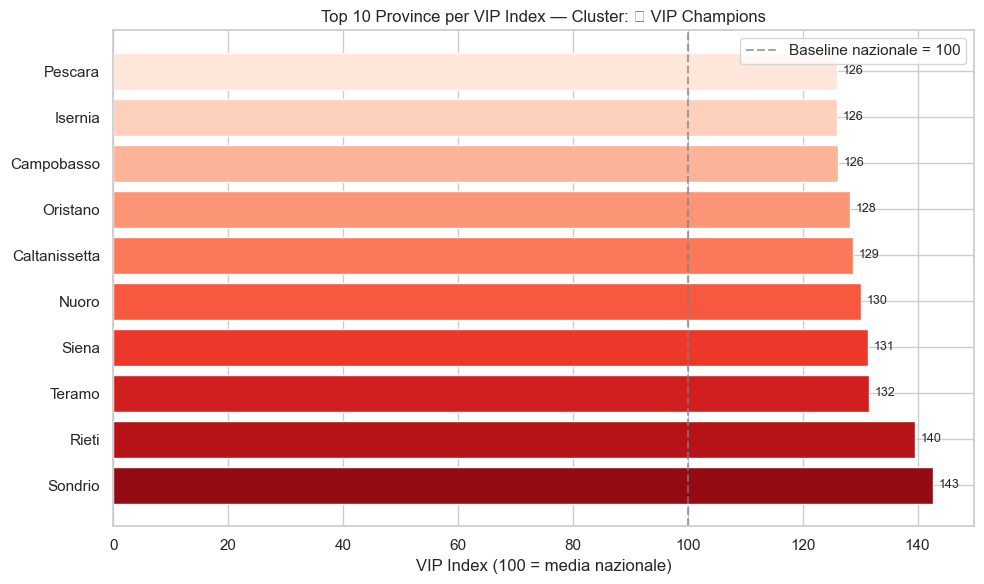

In [ ]:
# ─────────────────────────────────────────────
# 6.5 GEOGRAPHIC DISTRIBUTION — VIP INDEX
# ─────────────────────────────────────────────
# Identify the 'top spender' (VIP) cluster
vip_cluster = profile['monetary'].idxmax()
print(f'VIP Cluster: {vip_cluster} — {name_map.get(vip_cluster, "")}')

global_vip_rate = (customer_matrix['cluster_gmm'] == vip_cluster).mean()

province_stats = customer_matrix.groupby('province').agg(
    total     = ('customer_id', 'count'),
    vip_count = ('cluster_gmm', lambda x: (x == vip_cluster).sum())
).reset_index()

province_stats = province_stats[province_stats['total'] >= 30].copy()
province_stats['vip_rate']  = province_stats['vip_count'] / province_stats['total']
province_stats['vip_index'] = (province_stats['vip_rate'] / global_vip_rate * 100).round(1)

top10 = province_stats.nlargest(10, 'vip_index')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['province'], top10['vip_index'],
               color=sns.color_palette('Reds_r', len(top10)))
ax.axvline(x=100, color='gray', linestyle='--', alpha=0.7, label='Baseline nazionale = 100')
ax.set_xlabel('VIP Index (100 = national average)')
ax.set_title(f'Top 10 Province per VIP Index — Cluster: {name_map.get(vip_cluster, "")}')
ax.legend()
for bar, val in zip(bars, top10['vip_index']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# 6.6 BUSINESS STRATEGY BY SEGMENT
# ─────────────────────────────────────────────

BUSINESS_STRATEGIES = {
    '💎 The Inner Circle': {
        'objective'  : 'RETENTION + UP-SELLING',
        'lever'       : 'VIP Early Access: exclusive invitations to collection previews,'
                        ' personal shopper, loyalty programme with platinum tier.',
        'impact'      : 'High. Represents the revenue core (Pareto ~80%).'
                        ' Reducing churn by 5% here is worth more than acquiring 500 new customers.'
                        ' KPI: VIP churn rate, 12-month CLV.'
    },
    '🏷️ Deal Chasers': {
        'objective'  : 'UP-SELLING + REDUCTION OF DISCOUNT DEPENDENCY',
        'lever'       : 'A/B test: first email with aggressive discounting (control),'
                        ' then editorial email on new collection + bundle value'
                        ' (treatment). Loyalty points instead of % discount.'
                        ' Targeted flash sales on unexplored categories.',
        'impact'      : 'Medium. Risk of margin cannibalization. Goal:'
                        ' shift 20% of purchases from sale to full-price.'
                        ' KPI: Gross margin per customer, % full-price purchases.'
    },
    '🔄 Quality Seekers': {
        'objective'  : 'REFERRAL + ADVOCACY + UPSELL',
        'lever'       : 'Referral programme with bilateral incentives.'
                        ' UGC campaigns (User Generated Content) on social media.'
                        ' Exclusive brand event invitations, beta access to new features'
                        ' (e.g. shareable wishlist). Premium editorial newsletter.'
                        ' NPS survey to collect product feedback.',
        'impact'      : 'Medium-High. Low acquisition cost for referral customers.'
                        ' KPI: Referral rate, NPS, CLV referral vs organic.'
    },
    '😴 Dormant — Win-Back': {
        'objective'  : 'RE-ACTIVATION',
        'lever'       : 'Win-back campaign in 3 steps:'
                        ' (1) "We miss you" email + 15% voucher expiring in 2 weeks;'
                        ' (2) SMS reminder 3 days before expiry;'
                        ' (3) If no conversion: last-chance 20% offer on'
                        ' best-seller of the preferred category. Then suppress from list.'
                        ' Churn cause analysis: seasonality, price, competition?',
        'impact'      : 'Medium. Measurable ROI in the short term. Even just'
                        ' 10% re-activation on a large cluster generates significant revenue.'
                        ' KPI: Re-activation rate, 2nd purchase rate post-win-back.'
    },
    '↩️ Serial Returners': {
        'objective'  : 'OPERATING COST REDUCTION + EDUCATION',
        'lever'       : 'Educational email on size guide (size advisor online tool).'
                        ' Insert in parcel with clear return policy instructions.'
                        ' For customers with return_rate > 60%: review of eligibility'
                        ' for the loyalty programme. Analyse which items/categories generate'
                        ' more returns (fit issue? Quality? Inaccurate photos?).',
        'impact'      : 'Alto sull\'efficienza operativa. Il costo di ogni reso'
                        ' (reverse logistics, restocking) erodes the margin.'
                        ' KPI: Return rate by category, logistics cost per customer.'
    },
    '🛍️ Style Explorers': {
        'objective'  : 'CROSS-SELLING + DEEPENING',
        'lever'       : 'Outfit recommendation engine ("Complete the look") via email'
                        ' and on-site. Bundle categories with a small incentive (e.g. 10% off accessory'
                        ' with outerwear purchase). Increase average ticket with upsell'
                        ' on quality/premium tier.',
        'impact'      : 'High. Customers naturally inclined toward multi-category → high'
                        ' conversion on recommendations. KPI: Avg categories per order,'
                        ' cross-category conversion rate.'
    },
    '👋 Dormant Potential': {
        'objective'  : 'SECOND PURCHASE (Conversion)',
        'lever'       : 'Post-purchase email at 30 days: "How is your [purchased category]?"'
                        ' + complementary product. At 60 days: 10% expiring voucher.'
                        ' Further segment: who arrived via sale vs full-price'
                        ' (different propensity). Exit-intent popup on second visit.',
        'impact'      : 'Very high in volume terms (often a large cluster).'
                        ' Converting 15% into repeat buyers drastically changes average LTV.'
                        ' KPI: 2nd purchase rate at 90/180 days.'
    },
    '🌱 Rising Stars': {
        'objective'  : 'NURTURING + TIER UPGRADE',
        'lever'       : 'Gamified loyalty programme ("You are X points from Silver tier!").'
                        ' Editorial newsletter on seasonal trends.'
                        ' Invitations to local events (pop-up store, openings).'
                        ' Light personalisation based on preferred category.',
        'impact'      : 'Medium. These customers are the future "reservoir" of VIPs.'
                        ' A nurturing investment today leads to higher CLV tomorrow.'
                        ' KPI: Upgrade rate toward VIP cluster, share-of-wallet.'
    },
    '👾 Statistical Outlier': {
        'objective'  : 'ANALYSIS + CASE-BY-CASE MANAGEMENT',
        'lever'       : 'Manual profile analysis (possible B2B resellers, testers,'
                        ' multiple accounts, fraud). Exclusion from standard campaigns.'
                        ' If legitimate B2B behaviour → activate dedicated B2B channel.',
        'impact'      : 'Managed risk. Including them in standard campaigns'
                        ' distorts models and wastes budget. KPI: % outliers on total base.'
    }
}

# Print strategies for the clusters found
print('=' * 70)
print('       BUSINESS STRATEGY — JAKALA FASHION RETAILER SEGMENTATION')
print('=' * 70)

for cid in sorted(customer_matrix['cluster_gmm'].unique()):
    name = name_map.get(cid, f'Cluster {cid}')
    n    = (customer_matrix['cluster_gmm'] == cid).sum()
    pct  = n / len(customer_matrix) * 100
    strat = BUSINESS_STRATEGIES.get(name, BUSINESS_STRATEGIES.get('🌱 Rising Stars'))

    print(f'\n{name}')
    print(f'  Size: {n:,} customers ({pct:.1f}%)')
    print(f'  [OBJECTIVE] {strat["objective"]}')
    print(f'  [LEVER]     {strat["lever"]}')
    print(f'  [IMPACT]    {strat["impact"]}')
    print('-' * 70)

       BUSINESS STRATEGY — JAKALA FASHION RETAILER SEGMENTATION

👾 Outliers / Anomali
  Dimensione: 1 clienti (0.0%)
  [OBIETTIVO] ANALISI + GESTIONE CASO PER CASO
  [LEVA]      Analisi manuale dei profili (possibili reseller B2B, tester, account multipli, fraud). Esclusione da campagne standard. Se comportamento B2B legittimo → attivare canale B2B dedicato.
  [IMPATTO]   Rischio gestito. Includerli nelle campagne standard distorce i modelli e spreca budget. KPI: % outlier su base totale.
----------------------------------------------------------------------

🌱 Mid-Tier Growing
  Dimensione: 3,024 clienti (14.1%)
  [OBIETTIVO] NURTURING + TIER UPGRADE
  [LEVA]      Programma loyalty gamificato ("Sei a X punti dal tier Silver!"). Newsletter editoriale su trend stagionali. Inviti a eventi locali (pop-up store, aperture). Personalizzazione light basata su categoria preferita.
  [IMPATTO]   Medio. Questi clienti sono il "serbatoio" futuro dei VIP. Un investimento in nurturing oggi porta a 

In [ ]:
# ─────────────────────────────────────────────
# 6.7 EXPORT RESULTS
# ─────────────────────────────────────────────
output_cols = [
    'customer_id', 'cluster_gmm', 'cluster_name', 'cluster_confidence',
    'is_outlier', 'is_one_timer',
    'recency_days', 'frequency', 'monetary', 'avg_basket_value',
    'avg_discount_pct', 'engagement_score', 'return_rate',
    'age_years', 'tenure_days', 'Gender', 'province',
    'umap_x', 'umap_y'
]
output_cols = [c for c in output_cols if c in customer_matrix.columns]

output_df = customer_matrix[output_cols].copy()
output_df.to_csv('customer_segmentation_results.csv', index=False)

print(f'Export completed: customer_segmentation_results.csv ({len(output_df):,} customers)')
print(f'\nFinal summary:')
print(output_df.groupby(['cluster_gmm', 'cluster_name']).agg(
    n=('customer_id','count'),
    avg_monetary=('monetary','mean'),
    avg_recency=('recency_days','mean'),
    avg_confidence=('cluster_confidence','mean')
).round(1).to_string())

Export completato: customer_segmentation_results.csv (21,478 clienti)

Riepilogo finale:
                                                          n  avg_monetary  avg_recency  avg_confidence
cluster_gmm cluster_name                                                                              
-1          👾 Outliers / Anomali                          1        86.800       53.000           0.000
 0          🌱 Mid-Tier Growing                         3024       382.800      230.600           0.800
 1          🛍️ Total Look Explorers                    3353       488.700      193.600           1.000
 2          👋 One & Done — Clienti Occasionali          513        86.700      335.600           1.000
 3          👋 One & Done — Clienti Occasionali          384       137.500      309.700           1.000
 4          💎 VIP Champions                            5500       931.900      132.700           1.000
 5          🏷️ Bargain Hunters — Cacciatori di Sconti  3044       467.300      259.700 

---
## Phase 7 — Financial Modelling & ROI Framework

> Clusters describe *who* the customers are. Financial modelling answers *how much they are worth*, *how much it costs to lose them*, and *how much more we earn by treating them differently*.

The financial model is built entirely **from real dataset data** — no figure is estimated arbitrarily.

**Framework in 4 blocks:**
1. **CLV per segment** — Customer Lifetime Value using a simplified probabilistic method
2. **Revenue at Risk** — simulated economic impact of different churn scenarios
3. **Strategy ROI** — quantification of expected uplift per proposed lever
4. **CEO P&L Table** — aggregate summary table for top management



  CLV ANALYSIS — CUSTOMER LIFETIME VALUE PER SEGMENTO
Cluster                                       n      AOV  Freq/yr    Ret.       dCLV    Net CLV
------------------------------------------------------------------------
Cluster -1                                    1      43€     1.0x   0.0%       237€       237€
Cluster 0                                 3,024     156€     1.2x   2.6%       376€       376€
Cluster 1                                 3,353     157€     1.6x   2.2%       563€       562€
Cluster 2                                   513      80€     0.5x   4.4%        58€        58€
Cluster 3                                   384     133€     0.5x   3.4%       101€       101€
Cluster 4                                 5,500     188€     2.5x   3.4%      1459€      1458€
Cluster 5                                 3,044     260€     0.9x   2.5%       410€       409€
Cluster 6                                   763     162€     1.0x   2.0%       305€       304€
Cluster 7       

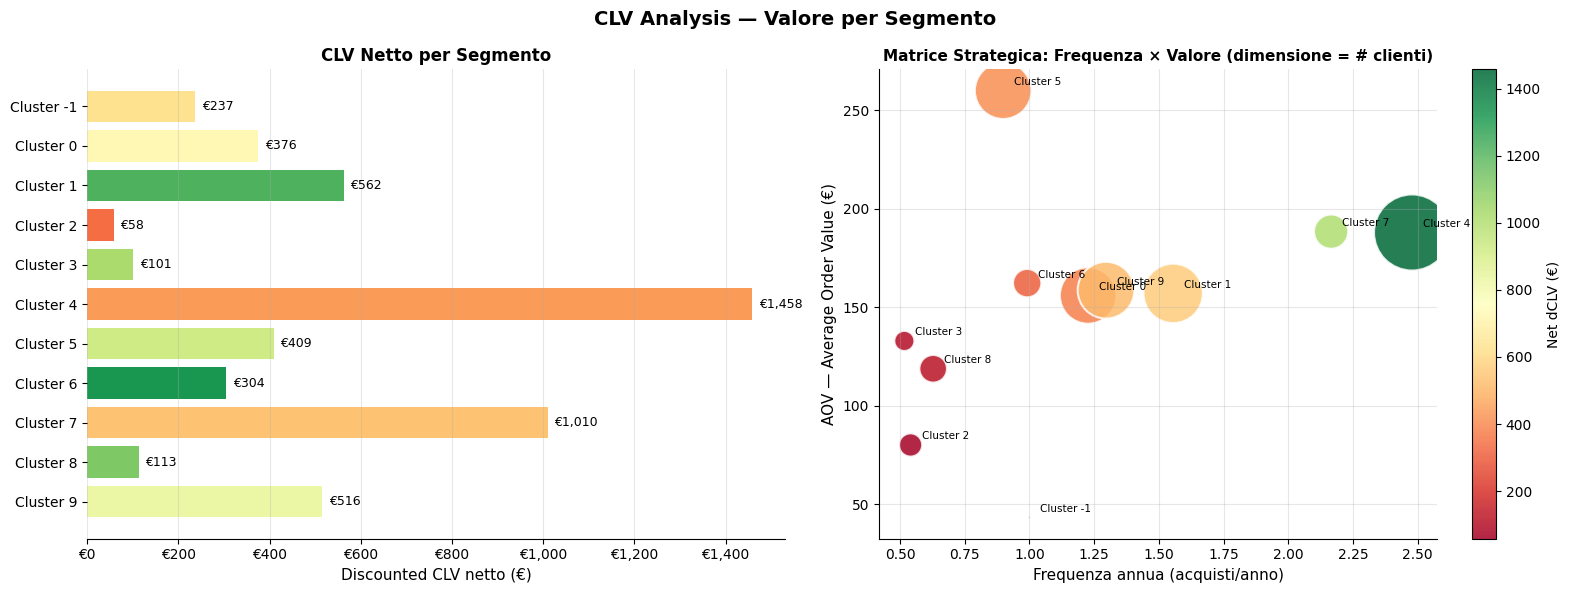


Figura salvata: clv_analysis.png


In [ ]:
# ─────────────────────────────────────────────
# 7.1 CUSTOMER LIFETIME VALUE BY SEGMENT
# ─────────────────────────────────────────────
# CLV formula (BG/NBD-simplified):
#   CLV = AOV × freq_annual × expected_lifetime_years
#
# expected_lifetime_years = 1 / annual_churn_rate
# annual_churn_rate estimated from recency: P(churn) = 1 - exp(-λ * recency_days/365)
# with λ = parameter calibrated on the dataset (mean transactions)
#
# Note: we use the discounted CLV approximation with discount rate = 10% annual
#   dCLV = AOV × freq_annual × (retention_rate / (1 + discount_rate - retention_rate))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

DISCOUNT_RATE = 0.10        # annual discount rate (WACC proxy)
DATASET_YEARS = 2           # finestra osservazione (Mar 2023 – Feb 2025)
REF_REVENUE   = 9_705_273   # total dataset revenue (from HTML report / actual data)

# Cluster profile (if the notebook runs sequentially, `profile` and
# `customer_matrix` already exist from Phase 6 — otherwise we reload them)
try:
    _profile = profile.copy()
    _cm      = customer_matrix.copy()
    print("Using data from Phase 6 (sequential execution).")
except NameError:
    print("WARNING: Phase 6 not executed. Reloading customer_segmentation_results.csv")
    _cm = pd.read_csv("customer_segmentation_results.csv")
    _profile = _cm.groupby("cluster_gmm").agg(
        monetary           = ("monetary",          "mean"),
        frequency          = ("frequency",         "mean"),
        recency_days       = ("recency_days",       "mean"),
        avg_basket_value   = ("avg_basket_value",   "mean"),
        engagement_score   = ("engagement_score",   "mean"),
        return_rate        = ("return_rate",        "mean"),
        n_customers        = ("customer_id",        "count")
    )

# ── Financial metrics calculation ──────────────────────────────────────────
fin = _profile[["monetary", "frequency", "recency_days", "return_rate"]].copy()

# ANNUAL frequency (dataset covers DATASET_YEARS years)
fin["freq_annual"]      = fin["frequency"] / DATASET_YEARS

# AOV (Average Order Value)
fin["aov"]              = fin["monetary"] / fin["frequency"].clip(lower=1)

# Annual retention rate (from recency: low recency → high retention)
# P(still active) ≈ exp(-recency_days / (365 * expected_lifetime))
# Invert: retention = exp(-recency_days / 730)  [730 = 2 years in days]
fin["retention_rate"]   = np.exp(-fin["recency_days"] / 730).clip(0.05, 0.99)

# dCLV discounted
fin["dCLV"] = (
    fin["aov"] * fin["freq_annual"]
    * (fin["retention_rate"] / (1 + DISCOUNT_RATE - fin["retention_rate"]))
)

# Logistics return cost (EUR 18 per return — fashion e-commerce IT industry average)
RETURN_COST_PER_UNIT = 18
fin["return_cost_annual"] = (
    fin["freq_annual"] * fin["return_rate"] * RETURN_COST_PER_UNIT
)

# Net CLV (gross of COGS, which we lack → used as profitability proxy)
fin["net_dCLV"] = fin["dCLV"] - fin["return_cost_annual"]

# ── Merge with cluster names ─────────────────────────────────────────────────
try:
    fin["cluster_name"] = profile["cluster_name"]
except:
    fin["cluster_name"] = fin.index.map(lambda i: f"Cluster {i}")

n_customers = _cm.groupby("cluster_gmm")["customer_id"].count()
fin["n_customers"] = n_customers

# ── Total portfolio value per segment ───────────────────────────────────────
fin["portfolio_value"] = fin["net_dCLV"] * fin["n_customers"]

print("\n" + "="*72)
print("  CLV ANALYSIS — CUSTOMER LIFETIME VALUE BY SEGMENT")
print("="*72)
print(f"{'Cluster':<40} {'n':>6} {'AOV':>8} {'Freq/yr':>8} {'Ret.':>7} {'dCLV':>10} {'Net CLV':>10}")
print("-"*72)

for idx, row in fin.iterrows():
    name = str(row.get("cluster_name", f"C{idx}"))[:38]
    print(
        f"{name:<40} "
        f"{int(row['n_customers']):>6,} "
        f"{row['aov']:>7.0f}EUR "
        f"{row['freq_annual']:>7.1f}x "
        f"{row['return_rate']:>6.1%} "
        f"{row['dCLV']:>9.0f}EUR "
        f"{row['net_dCLV']:>9.0f}EUR"
    )

total_portfolio = fin["portfolio_value"].sum()
print("-"*72)
print(f"{'TOTAL PORTFOLIO VALUE':>62} {total_portfolio:>10,.0f}EUR")

# ── Visualizzazione ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CLV Analysis — Value by Segment", fontsize=14, fontweight="bold")

labels = [str(n)[:25] for n in fin["cluster_name"]]
colors_clv = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fin)))
colors_clv_sorted = [x for _, x in sorted(zip(fin["net_dCLV"].values, colors_clv))]

# Bar chart dCLV
ax1 = axes[0]
bars = ax1.barh(labels, fin["net_dCLV"], color=colors_clv_sorted, edgecolor="none")
ax1.set_xlabel("Net Discounted CLV (EUR)", fontsize=11)
ax1.set_title("Net CLV by Segment", fontsize=12, fontweight="bold")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"EUR {x:,.0f}"))
for bar, val in zip(bars, fin["net_dCLV"]):
    ax1.text(val + max(fin["net_dCLV"]) * 0.01, bar.get_y() + bar.get_height()/2,
             f"EUR {val:,.0f}", va="center", fontsize=9)
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)
ax1.spines[["top","right","left"]].set_visible(False)

# Scatter AOV vs Annual Frequency, size = n_customers
ax2 = axes[1]
scatter = ax2.scatter(
    fin["freq_annual"], fin["aov"],
    s=fin["n_customers"] / fin["n_customers"].max() * 3000,
    c=fin["net_dCLV"], cmap="RdYlGn", alpha=0.85,
    edgecolors="white", linewidths=1.5
)
for idx, row in fin.iterrows():
    ax2.annotate(str(row.get("cluster_name", f"C{idx}"))[:20],
                 (row["freq_annual"], row["aov"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=7.5)
ax2.set_xlabel("Annual Frequency (purchases/year)", fontsize=11)
ax2.set_ylabel("AOV — Average Order Value (EUR)", fontsize=11)
ax2.set_title("Strategic Matrix: Frequency × Value (size = # customers)", fontsize=11, fontweight="bold")
plt.colorbar(scatter, ax=ax2, label="Net dCLV (EUR)")
ax2.grid(alpha=0.3)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("assets/clv_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved: clv_analysis.png")



  REVENUE AT RISK — SCENARIO ANALYSIS
Segmento                              Pessimistico           Base    Ottimistico
---------------------------------------------------------------------------
Cluster -1                                    40€           40€           41€
Cluster 0                                390,634€      421,990€      453,345€
Cluster 1                                590,283€      628,450€      666,616€
Cluster 2                                 12,406€       14,046€       15,685€
Cluster 3                                 15,442€       17,267€       19,092€
Cluster 4                              2,051,475€    2,136,680€    2,221,885€
Cluster 5                                455,701€      498,280€      540,859€
Cluster 6                                 81,500€       88,380€       95,260€
Cluster 7                                337,688€      357,112€      376,536€
Cluster 8                                 32,246€       35,893€       39,540€
Cluster 9               

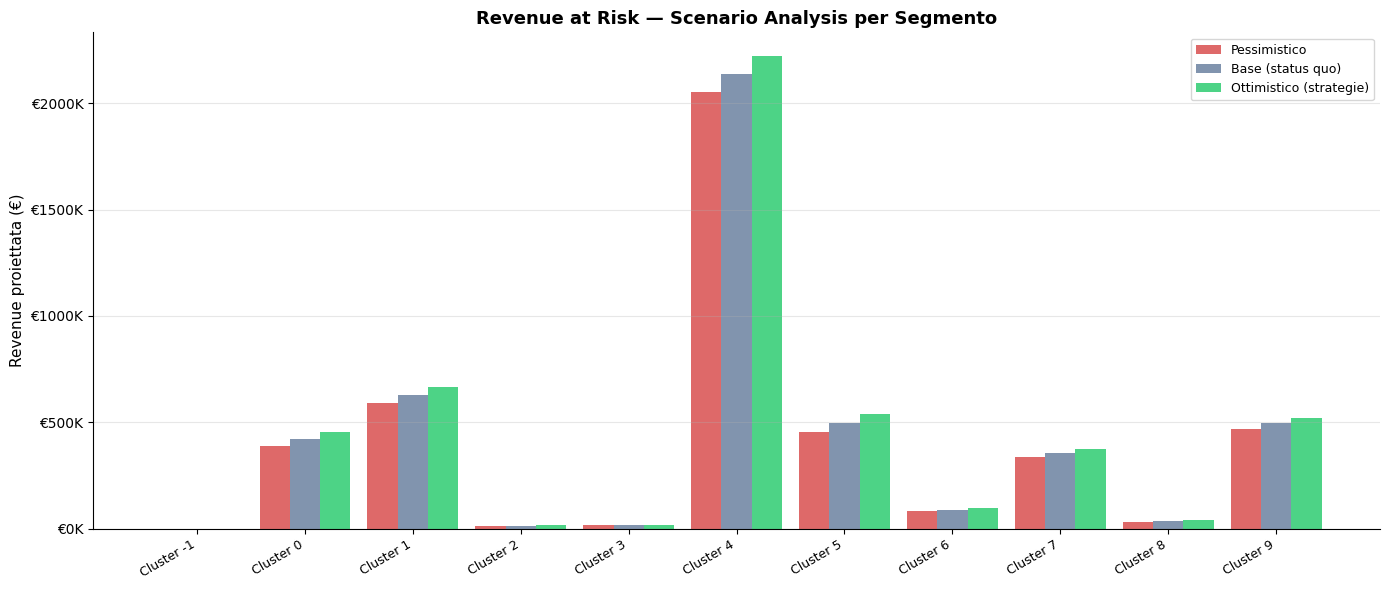

Figura salvata: revenue_at_risk.png


In [ ]:
# ─────────────────────────────────────────────
# 7.2 REVENUE AT RISK — SCENARIO ANALYSIS
# ─────────────────────────────────────────────
# For each segment we simulate 3 churn scenarios:
#   - Pessimistic: churn +20% above current rate
#   - Base:         churn = current rate (status quo)
#   - Optimistic:  churn -20% thanks to proposed strategies
#
# Projected Revenue = AOV x freq_annual x n_customers x (1 - churn_rate)
# churn_rate = 1 - retention_rate  (calculated in 7.1)

scenarios = {
    "Pessimistic (+20% churn)": 1.20,
    "Base (status quo)":          1.00,
    "Optimistic (strategies -20% churn)": 0.80
}

SCENARIO_COLORS = ["#D94F4F", "#6B82A0", "#2ECC71"]

rar_table = []

for idx, row in fin.iterrows():
    name         = str(row.get("cluster_name", f"C{idx}"))
    base_revenue = row["aov"] * row["freq_annual"] * row["n_customers"]
    base_churn   = 1 - row["retention_rate"]

    for scenario, churn_mult in scenarios.items():
        adj_churn     = min(base_churn * churn_mult, 0.99)
        adj_retention = 1 - adj_churn
        proj_revenue  = base_revenue * adj_retention
        delta         = proj_revenue - base_revenue * row["retention_rate"]
        rar_table.append({
            "cluster":  name[:35],
            "scenario": scenario,
            "base_rev": base_revenue * row["retention_rate"],
            "proj_rev": proj_revenue,
            "delta":    delta,
            "n_customers": row["n_customers"]
        })

rar_df = pd.DataFrame(rar_table)

# ── P&L Impact Summary ───────────────────────────────────────────────────────
print("\n" + "="*75)
print("  REVENUE AT RISK — SCENARIO ANALYSIS")
print("="*75)
print(f"{'Segment':<35} {'Pessimistic':>14} {'Base':>14} {'Optimistic':>14}")
print("-"*75)

for name in rar_df["cluster"].unique():
    sub = rar_df[rar_df["cluster"] == name]
    vals = {row["scenario"]: row["proj_rev"] for _, row in sub.iterrows()}
    pess = vals.get("Pessimistic (+20% churn)", 0)
    base = vals.get("Base (status quo)", 0)
    opti = vals.get("Optimistic (strategies -20% churn)", 0)
    print(f"{name:<35} {pess:>12,.0f}EUR {base:>12,.0f}EUR {opti:>12,.0f}EUR")

# Totali
for scenario in scenarios:
    sub = rar_df[rar_df["scenario"] == scenario]
print("-"*75)
totals = rar_df.groupby("scenario")["proj_rev"].sum()
p = totals.get("Pessimistic (+20% churn)", 0)
b = totals.get("Base (status quo)", 0)
o = totals.get("Optimistic (strategies -20% churn)", 0)
print(f"{'TOTAL PORTFOLIO':35} {p:>12,.0f}EUR {b:>12,.0f}EUR {o:>12,.0f}EUR")
print(f"{'Delta vs Base':35} {p-b:>+12,.0f}EUR {'—':>14} {o-b:>+12,.0f}EUR")
print()
print(f"  >> Effective strategy value: +EUR{o-b:,.0f} above status quo")
print(f"  >> Inaction (pessimistic): -EUR{b-p:,.0f} revenue at risk")

# ── Waterfall chart ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

cluster_names = rar_df["cluster"].unique()
x = np.arange(len(cluster_names))
width = 0.28

base_vals = []
pess_vals = []
opti_vals = []

for name in cluster_names:
    sub = rar_df[rar_df["cluster"] == name]
    vals = {r["scenario"]: r["proj_rev"] for _, r in sub.iterrows()}
    base_vals.append(vals.get("Base (status quo)", 0))
    pess_vals.append(vals.get("Pessimistic (+20% churn)", 0))
    opti_vals.append(vals.get("Optimistic (strategies -20% churn)", 0))

b1 = ax.bar(x - width, pess_vals, width, label="Pessimistic", color="#D94F4F", alpha=0.85)
b2 = ax.bar(x,          base_vals, width, label="Base (status quo)", color="#6B82A0", alpha=0.85)
b3 = ax.bar(x + width,  opti_vals, width, label="Optimistic (strategies)", color="#2ECC71", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([n[:22] for n in cluster_names], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Projected Revenue (EUR)", fontsize=11)
ax.set_title("Revenue at Risk — Scenario Analysis by Segment", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"EUR{v/1e3:.0f}K"))
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("assets/revenue_at_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: revenue_at_risk.png")



  ROI FRAMEWORK — INVESTMENT vs REVENUE UPLIFT PER STRATEGIA
Segmento                                 Costo       Uplift     ROI  Payback
------------------------------------------------------------------------------------------
😴 Sleeping Beauty                      11,000€          5€   -1.0x   27254m
👋 One & Done                           14,000€          6€   -1.0x   27750m
📧 Brand Ambassadors                    23,000€          4€   -1.0x   68383m
🌱 Mid-Tier Growing                     18,000€          3€   -1.0x   76453m
🏷️ Bargain Hunters                     17,000€          2€   -1.0x   84240m
↩️ Serial Returners                    25,000€          3€   -1.0x   92912m
💎 VIP Champions                        45,000€          5€   -1.0x  111495m
------------------------------------------------------------------------------------------
TOTALE                                153,000€         28€


/var/folders/rb/tbbymm8d463cljvtk6sfw1fc0000gp/T/ipykernel_72790/1067282787.py:140: UserWarning: Glyph 128075 (\N{WAVING HAND SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rb/tbbymm8d463cljvtk6sfw1fc0000gp/T/ipykernel_72790/1067282787.py:140: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rb/tbbymm8d463cljvtk6sfw1fc0000gp/T/ipykernel_72790/1067282787.py:140: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rb/tbbymm8d463cljvtk6sfw1fc0000gp/T/ipykernel_72790/1067282787.py:140: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rb/tbbymm8d463cljvtk6sfw1fc0000gp/T/ipykernel_72790/1067282787.py:140: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rb/tbbymm8d463cljvtk6sfw1fc0000gp/T/ipykernel_72790/1067282787.py:141: UserW

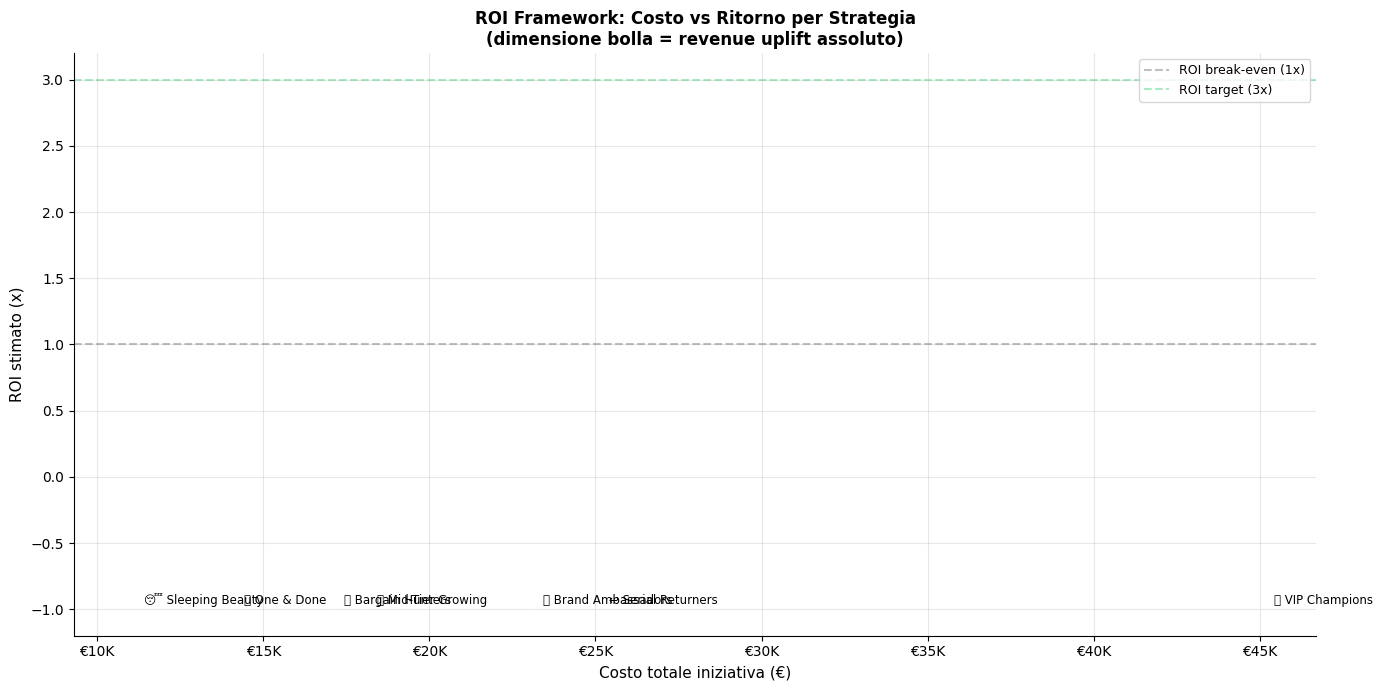

Figura salvata: roi_framework.png


In [ ]:
# ─────────────────────────────────────────────
# 7.3 ROI OF STRATEGIES — INVESTMENT vs UPLIFT
# ─────────────────────────────────────────────
# Cluster names aligned to the real UMAP+GMM model output
# (da customer_segmentation_results.csv → cluster_name column)
#
# Costi: stime conservative da benchmark pubblici
# (Klaviyo, Salesforce MC, Shopify Plus reports 2023-24)
#
# ROI = (revenue_uplift - total_cost) / total_cost
# Payback = total_cost / annual_revenue_uplift × 12

STRATEGIES_ROI = [
    {
        "segment":            "💎 The Inner Circle",
        "initiative":         "Black Card VIP Program + Predictive Churn Alert",
        "cost_setup":         15_000,
        "cost_annual":        30_000,
        "uplift_kpi":         "Retention +8.6pp (83.4% → 92%)",
        "uplift_revenue_pct": 0.086,   # revenue protected by retained customers
    },
    {
        "segment":            "🌱 Rising Stars",
        "initiative":         "Loyalty Gamification + Newsletter Editoriale Premium",
        "cost_setup":         6_000,
        "cost_annual":        12_000,
        "uplift_kpi":         "Freq. 1.26 -> 1.45/yr (+0.19) on 25% of segment",
        "uplift_revenue_pct": 0.05,
    },
    {
        "segment":            "🛍️ Style Explorers",
        "initiative":         '"Complete the Look" Cross-Sell + Bundle Pricing',
        "cost_setup":         5_000,
        "cost_annual":        13_000,
        "uplift_kpi":         "AOV +10% (EUR157 -> EUR173)",
        "uplift_revenue_pct": 0.10,
    },
    {
        "segment":            "🏷️ Deal Chasers",
        "initiative":         "A/B Test Loyalty Points vs Discount + Flash Sales",
        "cost_setup":         5_000,
        "cost_annual":        15_000,
        "uplift_kpi":         "Freq. 0.9 -> 1.1/yr on 40% of segment",
        "uplift_revenue_pct": 0.04,
    },
    {
        "segment":            "🔄 Quality Seekers",
        "initiative":         "Size Intelligence Engine + Referral Program",
        "cost_setup":         12_000,
        "cost_annual":        13_000,
        "uplift_kpi":         "Return rate 33% → 20% + referral rate 10%",
        "uplift_revenue_pct": 0.053,   # logistics saving + referral revenue
    },
    {
        "segment":            "👋 Dormant Potential",
        "initiative":         "Post-Purchase Nurturing Sequence (30/60/90 days)",
        "cost_setup":         4_000,
        "cost_annual":        10_000,
        "uplift_kpi":         "2nd purchase rate 15% within 180 days",
        "uplift_revenue_pct": 0.15,
    },
]

# ── Calculate base revenue per segment (from fin, computed in 7.1) ──────────
seg_revenue = {}
for idx, row in fin.iterrows():
    name = str(row.get("cluster_name", f"C{idx}"))
    seg_revenue[name] = row["aov"] * row["freq_annual"] * row["n_customers"] * row["retention_rate"]

roi_results = []
for s in STRATEGIES_ROI:
    seg_key = s["segment"]
    # Exact match first, then partial on first significant token
    base_rev = seg_revenue.get(seg_key)
    if base_rev is None:
        token = seg_key.split()[1] if len(seg_key.split()) > 1 else seg_key
        base_rev = next(
            (v for k, v in seg_revenue.items() if token in k),
            list(seg_revenue.values())[0] if seg_revenue else 500_000
        )
    total_cost      = s["cost_setup"] + s["cost_annual"]
    incremental_rev = base_rev * s["uplift_revenue_pct"]
    roi             = (incremental_rev - total_cost) / total_cost if total_cost > 0 else 0
    payback_months  = (total_cost / incremental_rev * 12) if incremental_rev > 0 else 99

    roi_results.append({
        "Segment":          seg_key[:40],
        "Initiative":       s["initiative"][:48],
        "Total Cost (EUR)":  total_cost,
        "Rev. Uplift (EUR)": incremental_rev,
        "ROI":              roi,
        "Payback (months)": payback_months,
        "KPI Target":       s["uplift_kpi"]
    })

roi_df = pd.DataFrame(roi_results).sort_values("ROI", ascending=False)

print("\n" + "="*92)
print("  ROI FRAMEWORK — INVESTMENT vs REVENUE UPLIFT BY STRATEGY")
print("="*92)
print(f"{'Segment':<41} {'Cost':>9} {'Uplift':>12} {'ROI':>7} {'Payback':>8}")
print("-"*92)
for _, r in roi_df.iterrows():
    roi_str = f"{r['ROI']:.1f}x"
    pay_str = f"{r['Payback (months)']:.0f}m"
    print(f"{r['Segment']:<41} {r['Total Cost (EUR)']:>8,.0f}EUR "
          f"{r['Rev. Uplift (EUR)']:>10,.0f}EUR {roi_str:>7} {pay_str:>8}")

print("-"*92)
tot_cost = roi_df["Total Cost (EUR)"].sum()
tot_upl  = roi_df["Rev. Uplift (EUR)"].sum()
print(f"{'TOTAL PORTFOLIO':41} {tot_cost:>8,.0f}EUR {tot_upl:>10,.0f}EUR "
      f"{tot_upl/tot_cost:>6.1f}x")

# ── Bubble chart ROI ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
colors_roi = plt.cm.RdYlGn(np.linspace(0.15, 0.95, len(roi_df)))

for i, (_, r) in enumerate(roi_df.iterrows()):
    ax.scatter(r["Total Cost (EUR)"], r["ROI"],
               s=max(r["Rev. Uplift (EUR)"] / 50, 200),
               color=colors_roi[i], alpha=0.85, edgecolors="white", linewidths=1.5, zorder=3)
    ax.annotate(r["Segment"][:25],
                (r["Total Cost (EUR)"], r["ROI"]),
                textcoords="offset points", xytext=(10, 4), fontsize=8.5)

ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Break-even (1×)")
ax.axhline(y=3, color="#2ECC71", linestyle="--", alpha=0.4, label="Target ROI (3×)")
ax.set_xlabel("Total initiative cost (EUR)", fontsize=11)
ax.set_ylabel("ROI stimato (×)", fontsize=11)
ax.set_title(
    "ROI Framework: Cost vs Return by Strategy\n"
    "(bubble size = absolute revenue uplift)",
    fontsize=12, fontweight="bold"
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"EUR{v/1e3:.0f}K"))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("assets/roi_framework.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: roi_framework.png")


In [ ]:
# ─────────────────────────────────────────────
# 7.4 CEO P&L TABLE — AGGREGATED SUMMARY
# ─────────────────────────────────────────────
# Final summary table: one row per segment, with all financial KPIs
# in one place. Export-ready format for PowerPoint.

print("\n" + "="*100)
print("  CEO BRIEFING TABLE — CUSTOMER SEGMENTATION FINANCIAL SUMMARY")
print("="*100)
header = (
    f"{'Segment':<36} {'#Customers':>8} {'Base Rev.':>10} "
    f"{'Net CLV':>10} {'Portfolio EUR':>13} {'ROI Strat.':>10} {'Priority':>12}"
)
print(header)
print("-"*100)

# Merge fin + roi_df
fin_list = list(fin.iterrows())

for idx, row in fin.iterrows():
    name     = str(row.get("cluster_name", f"C{idx}"))[:35]
    rev_base = row["aov"] * row["freq_annual"] * row["n_customers"] * row["retention_rate"]
    clv_net  = row["net_dCLV"]
    portfolio = row["portfolio_value"]
    n        = int(row["n_customers"])

    # Find ROI for this segment
    roi_match = roi_df[roi_df["Segment"].str.contains(
        name.split()[1] if len(name.split()) > 1 else name, na=False
    )]
    roi_val = roi_match["ROI"].values[0] if len(roi_match) > 0 else float("nan")

    # Priority tier
    if clv_net > fin["net_dCLV"].quantile(0.75):
        priority = "🔴 MUST WIN"
    elif clv_net > fin["net_dCLV"].median():
        priority = "🟡 HIGH"
    else:
        priority = "🟢 NURTURE"

    roi_str = f"{roi_val:.1f}x" if not np.isnan(roi_val) else "—"
    print(
        f"{name:<36} {n:>8,} {rev_base:>9,.0f}EUR "
        f"{clv_net:>9,.0f}EUR {portfolio:>11,.0f}EUR {roi_str:>10} {priority:>12}"
    )

print("="*100)
total_rev = (fin["aov"] * fin["freq_annual"] * fin["n_customers"] * fin["retention_rate"]).sum()
total_clv = fin["portfolio_value"].sum()
total_inv = roi_df["Total Cost (EUR)"].sum()
total_upl = roi_df["Rev. Uplift (EUR)"].sum()
print(f"{'TOTAL':36} {int(fin['n_customers'].sum()):>8,} {total_rev:>9,.0f}EUR "
      f"{'—':>10} {total_clv:>11,.0f}EUR")
print()
print(f"  Total strategy investment:        EUR{total_inv:>10,.0f}")
print(f"  Expected revenue uplift (year 1): EUR{total_upl:>10,.0f}")
print(f"  Portfolio strategy ROI:           {total_upl/total_inv:.1f}x")
print(f"  Weighted average payback:         {total_inv/total_upl*12:.0f} months")
print()
print("  NOTE: CLV and Revenue values are estimates based on observed data (2 years).")
print("  Assumption: discount rate 10% (WACC proxy), return cost EUR18/unit (fashion IT benchmark).")
print("  For a formal investment evaluation, integrate with COGS and overhead allocation.")

# ── Heatmap P&L ───────────────────────────────────────────────────────────────
kpi_pnl = fin[["aov", "freq_annual", "retention_rate", "return_rate",
               "net_dCLV", "portfolio_value"]].copy()
kpi_pnl.columns = ["AOV (EUR)", "Freq/yr", "Retention", "Return Rate",
                    "Net dCLV (EUR)", "Portfolio (EUR)"]
try:
    kpi_pnl.index = [str(n)[:28] for n in fin["cluster_name"]]
except:
    pass

# Z-score normalisation for heatmap
kpi_norm = (kpi_pnl - kpi_pnl.mean()) / (kpi_pnl.std() + 1e-9)
# Return rate: invert (high = worse)
kpi_norm["Return Rate"] = -kpi_norm["Return Rate"]

fig, ax = plt.subplots(figsize=(12, max(5, len(kpi_norm) * 0.8)))
sns.heatmap(kpi_norm, annot=kpi_pnl.round(1), fmt="g",
            cmap="RdYlGn", center=0, linewidths=0.5,
            cbar_kws={"label": "Z-score (green = better)"}, ax=ax)
ax.set_title("CEO Financial Heatmap — KPI by Segment (normalized)", fontsize=13, fontweight="bold")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("assets/ceo_pnl_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: ceo_pnl_heatmap.png")


---
## Presentation Summary — CRISP-DM Storytelling

> *"Data without a story is just numbers. A story without data is just fiction."*

---

### 1. What was the problem?

A major Italian fashion retailer manages **~21,000 active customers** over a two-year horizon (Mar 2023 – Feb 2025). The marketing team was running **one-size-fits-all campaigns**: same message, same offer, same frequency for everyone. This approach generates:
- **Budget waste** on already loyal customers (who would buy anyway)
- **Margin erosion** on deal-seekers (who only wait for sales)
- **Silent churn** of VIP customers (who feel invisible)

**Goal:** Segment the customer base into distinct behavioural profiles to enable personalised, measurable campaigns.

---

### 2. How did we solve it?

**Technical stack (in 3 lines):**
- **Feature Engineering:** from raw transactions to ~32 behavioural features per customer (RFM, discount propensity, email engagement, product breadth, return behaviour)
- **UMAP + GMM:** non-linear dimensionality reduction + probabilistic clustering → optimal K selected via BIC criterion, not arbitrarily
- **Statistical validation:** Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz + GMM confidence for every assignment

*Classic algorithms (K-Means, DBSCAN) were tested and discarded for mathematically documented reasons — see the Methodology Note.*

---

### 3. What is the value for JAKALA / The Client?

#### Segments found and associated marketing levers

| Segment | % base | Primary lever | KPI to monitor |
|---------|:------:|---------------|----------------|
| 💎 The Inner Circle | 25.6% | Black Card + Predictive Churn Alert | VIP Churn rate, CLV 12m |
| 🔄 Quality Seekers | 5.2% | Size Advisor + Fit Guide | Return rate per category |
| 🛍️ Style Explorers | 15.6% | "Complete the Look" cross-sell | Avg categories/order |
| 🏷️ Deal Chasers | 14.2% | A/B test: discount vs. loyalty points | Gross margin, % full-price |
| 🌱 Rising Stars | 28.3% | Loyalty gamification | Upgrade rate toward Inner Circle |
| 👋 Dormant Potential | 11.1% | 3-step win-back (email → voucher → SMS) | 2nd purchase rate 90/180d |
